## Parameter Definition

- "1 EXCEL TERMINADO AVISOS (CATA)" -> "cholitos_1"
- "2 EXCEL TERMINADO AVISOS (MATIAS)" -> "cholitos_2"
- "3 EXCEL TERMINADO AVISOS (SOFIA)" -> "cholitos_3"
- "4 EXCEL TERMINADO AVISOS (DIEGO)" -> "cholitos_4"
- "5 EXCEL TERMINADO AVISOS (MONTSERRAT)" -> "cholitos_5"

In [1]:
DATA_FOLDER = "../data"
ARCHIVOS = [f"cholitos_{i}.xlsx" for i in range(1, 6)]

## Library Imports

In [2]:
import os

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 12)

import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import importlib, subprocess, sys

pkg = "reportlab"
if importlib.util.find_spec(pkg) is None:  # type: ignore
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from datetime import datetime

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle
import textwrap
import math

from thefuzz import fuzz
import unidecode
import re

import nbformat
from nbconvert import PDFExporter
from traitlets.config import Config

from sklearn.preprocessing import LabelEncoder

In [3]:

def export_notebook_to_pdf(notebook_path, output_path=None):
    if output_path is None:
        output_path = os.path.splitext(notebook_path)[0] + ".pdf"

    print(f"Exporting '{notebook_path}' to '{output_path}'...")

    try:
        with open(notebook_path, encoding="utf-8") as f:
            nb = nbformat.read(f, as_version=4)

        c = Config()
        c.PDFExporter.latex_command = ["pdflatex", "{filename}", "-quiet"]
        
        c.PDFExporter.latex_header = r"""
        \usepackage[utf8]{inputenc}
        \usepackage[T1]{fontenc}
        \usepackage{amsmath}
        \usepackage{graphicx}
        """

        pdf_exporter = PDFExporter(config=c)
        pdf_data, _ = pdf_exporter.from_notebook_node(nb)

        with open(output_path, "wb") as f:
            f.write(pdf_data)

        print(f"✅ Successfully created PDF: {output_path}")

    except Exception as e:
        print(f"❌ Error exporting {notebook_path}: {e}")
        raise

## Consolidation of XLSX Files for `df_avisos_cholitos`

### `df_avisos_cholitos`

In [4]:
# Read and store DataFrames in a list
dfs_avisos_cholitos = []
for archivo in ARCHIVOS:
    ruta = os.path.join(DATA_FOLDER, archivo)
    df_temp = pd.read_excel(ruta)
    dfs_avisos_cholitos.append(df_temp)

# Concatenate all DataFrames
df_avisos_cholitos = pd.concat(dfs_avisos_cholitos, ignore_index=True, join="outer")

# --- Unification of "oreja" and "orejas" columns ---
if "oreja" in df_avisos_cholitos.columns or "orejas" in df_avisos_cholitos.columns:
    df_avisos_cholitos["orejas"] = df_avisos_cholitos.get(
        "orejas", pd.Series(dtype=object)
    )
    df_avisos_cholitos["orejas"] = df_avisos_cholitos["orejas"].combine_first(
        df_avisos_cholitos.get("oreja", pd.Series(dtype=object))
    )
    # Remove singular column if it exists
    if "oreja" in df_avisos_cholitos.columns:
        df_avisos_cholitos.drop(columns=["oreja"], inplace=True)

# Quick view
df_avisos_cholitos.head()

,id_aviso,primera_fecha,texto_original,titulo,nombre,sexo,edad,origen,color_piel,estatura,complexion,cara,ojos,cejas,pestañas,nariz,boca,labios,dientes,frente,menton,color_cabello,longitud_cabello,textura_cabello,peinado,cicatrices,viruelas,manchas,verrugas,quemaduras,amputaciones,tatuajes,camisa,pantalon,calzado,poncho,sombrero,pañuelo,accesorios,comentario,orejas,brazos,cabeza,traje,Unnamed: 39
0,1,9/08/1839,Una cria...,SE VENDE,NaN,F,23 á 24 ...,nacida e...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,30/10/1840,Se pagar...,UNA ONZA...,Maria Ur...,F,10 años,Chilena,blanco o...,estatura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,le falta...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,14/08/1841,El Jueve...,NaN,Melchora...,F,NaN,NaN,cholita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,21/08/1841,Se ha pe...,NaN,Santos,M,ocho años,NaN,cholito,NaN,"gordo, a...",cara red...,ojos gra...,NaN,NaN,nariz roma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chaqueta...,pantalon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,4/10/1841,De un ni...,PERDIDA,Abelino,M,dos años,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vestido...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_avisos_cholitos.info()

<class 'pandas.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_aviso          636 non-null    int64  
 1   primera_fecha     627 non-null    str    
 2   texto_original    627 non-null    str    
 3   titulo            447 non-null    str    
 4   nombre            554 non-null    str    
 5   sexo              615 non-null    str    
 6   edad              569 non-null    object 
 7   origen            159 non-null    str    
 8   color_piel        440 non-null    str    
 9   estatura          118 non-null    str    
 10  complexion        163 non-null    str    
 11  cara              238 non-null    str    
 12  ojos              174 non-null    str    
 13  cejas             13 non-null     str    
 14  pestañas          2 non-null      object 
 15  nariz             143 non-null    str    
 16  boca              80 non-null     str    
 17  labios  

### `df_fuentes`

In [6]:
# Read and concatenate all "Fuente" sheets
dfs_fuentes = []
for archivo in ARCHIVOS:
    ruta = os.path.join(DATA_FOLDER, archivo)
    df_fuente = pd.read_excel(ruta, sheet_name="Fuente")
    dfs_fuentes.append(df_fuente)

df_fuentes = pd.concat(dfs_fuentes, ignore_index=True, join="outer")

# Quick view
df_fuentes.head()

,numero_edicion_fuente,numero_pagina_fuente,fecha
0,79,1,09/08/1839
1,436,4,30/10/1840
2,437,4,31/10/1840
3,438,4,02/11/1840
4,439,4,03/11/1840


In [7]:
df_fuentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   numero_edicion_fuente  1228 non-null   int64
 1   numero_pagina_fuente   1228 non-null   int64
 2   fecha                  1228 non-null   str  
dtypes: int64(2), str(1)
memory usage: 40.9 KB


### `df_fuentes_por_aviso`

In [8]:
# Read and concatenate all "FuentesPorAviso" sheets
dfs_fuentes_por_aviso = []
for archivo in ARCHIVOS:
    ruta = os.path.join(DATA_FOLDER, archivo)
    df_fuente_aviso = pd.read_excel(ruta, sheet_name="FuentesPorAviso")
    dfs_fuentes_por_aviso.append(df_fuente_aviso)

df_fuentes_por_aviso = pd.concat(dfs_fuentes_por_aviso, ignore_index=True, join="outer")

# Quick view
df_fuentes_por_aviso.head()

,id_aviso,numero_edicion_fuente,numero_pagina_fuente
0,1,79,1.0
1,2,436,4.0
2,3,662,8.0
3,4,668,4.0
4,5,703,6.0


In [9]:
df_fuentes_por_aviso.info()

<class 'pandas.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_aviso               1199 non-null   int64  
 1   numero_edicion_fuente  1199 non-null   int64  
 2   numero_pagina_fuente   1196 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 28.2 KB


## Removal of Unwanted Records

In [10]:
# --- List of IDs to remove ---
ids_no_deseados_1 = [
    1,
    2,
    7,
    9,
    10,
    19,
    21,
    25,
    44,
    67,
    71,
    74,
    82,
    84,
    87,
    101,
    110,
    116,
    117,
    119,
]
ids_no_deseados_2 = [230]
ids_no_deseados_3 = []
ids_no_deseados_4 = [
    384,
    385,
    405,
    420,
    427,
    428,
    444,
    446,
    450,
    465,
]
ids_no_deseados_5 = [563, 575, 582, 586, 588, 595, 600, 601, 602, 607, 620]
ids_no_deseados = (
    ids_no_deseados_1
    + ids_no_deseados_2
    + ids_no_deseados_3
    + ids_no_deseados_4
    + ids_no_deseados_5
)

# --- Filter df_avisos_cholitos to remove records ---
df_avisos_cholitos = df_avisos_cholitos[
    ~df_avisos_cholitos["id_aviso"].isin(ids_no_deseados)
].reset_index(drop=True)

# --- Confirm removal ---
print(f"✅ Registros eliminados: {len(ids_no_deseados)}")
print(f"Registros actuales en df_avisos_cholitos: {len(df_avisos_cholitos)}")

✅ Registros eliminados: 42
Registros actuales en df_avisos_cholitos: 594


## Data Cleaning for `df_avisos_cholitos`

In [11]:
# Copy the dataset
df_avisos_cholitos = df_avisos_cholitos.copy()

# Convert any type of null to standard null.
for col in df_avisos_cholitos.columns:
    df_avisos_cholitos[col] = df_avisos_cholitos[col].replace(
        [
            "",
            " ",
            "nan",
            "NaN",
            "None",
            "none",
            "NULL",
            "null",
            "null ",
            "null  ",
            " null",
            "  null",
        ],
        pd.NA,
    )

# --- Removal of columns containing only nulls ---
if "tatuajes" in df_avisos_cholitos.columns:
    if df_avisos_cholitos["tatuajes"].isna().all():
        df_avisos_cholitos = df_avisos_cholitos.drop(columns=["tatuajes"])

# Columns that must retain uppercase letters
excepciones = []


# --- Advanced cleaning functions ---
def limpiar_texto_es(val):
    if pd.isna(val):
        return val
    val = str(val).strip().lower()
    val = val.replace("ñ", "__ene__")  # temporary placeholder
    val = unidecode.unidecode(val)  # remove accents
    val = val.replace("__ene__", "ñ")  # restore ñ
    val = re.sub(r"\s+", " ", val)  # normalize whitespace
    val = re.sub(r"[^\w\sñ]", "", val)  # remove punctuation except ñ
    return val


def unificar_valores_lexicos_avanzado(series, threshold=90):
    """Unifica valores muy similares en una columna, eligiendo como representante el más frecuente."""
    vc = series.value_counts()
    valores = vc.index.tolist()
    mapping = {}
    for val in valores:
        if val in mapping:
            continue
        similares = [v for v in valores if fuzz.ratio(val, v) >= threshold]
        # Select the most frequent value as representative
        rep = max(similares, key=lambda x: vc[x])
        for sim in similares:
            mapping[sim] = rep
    return series.map(lambda x: mapping.get(x, x))


# Iterate over all text columns
for col in df_avisos_cholitos.columns:
    if df_avisos_cholitos[col].dtype == "object" and col != "primera_fecha":
        # Clean text
        df_avisos_cholitos[col] = df_avisos_cholitos[col].map(limpiar_texto_es)
        # Unify lexically similar values (unless excluded)
        if col not in excepciones:
            df_avisos_cholitos[col] = unificar_valores_lexicos_avanzado(
                df_avisos_cholitos[col], threshold=90
            )

# --- Data type conversion ---
df_avisos_cholitos["id_aviso"] = df_avisos_cholitos["id_aviso"].astype("int64")
df_avisos_cholitos = df_avisos_cholitos.dropna(subset=["primera_fecha"])
df_avisos_cholitos["primera_fecha"] = (
    df_avisos_cholitos["primera_fecha"].astype(str).str.strip()
)
df_avisos_cholitos["primera_fecha"] = pd.to_datetime(
    df_avisos_cholitos["primera_fecha"], dayfirst=True, errors="coerce"
)


# If a column named Unnamed: 39 exists, remove it.
if "Unnamed: 39" in df_avisos_cholitos.columns:
    df_avisos_cholitos = df_avisos_cholitos.drop(columns=["Unnamed: 39"])
if "comentario" in df_avisos_cholitos.columns:
    df_avisos_cholitos = df_avisos_cholitos.drop(columns=["comentario"])

excluir = ["id_aviso", "primera_fecha", "texto_original"]
for col in df_avisos_cholitos.columns:
    if col not in excluir and df_avisos_cholitos[col].dtype == "object":
        df_avisos_cholitos[col] = df_avisos_cholitos[col].astype("category")

In [12]:
df_avisos_cholitos.info()

<class 'pandas.DataFrame'>
Index: 593 entries, 0 to 593
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_aviso          593 non-null    int64         
 1   primera_fecha     593 non-null    datetime64[us]
 2   texto_original    593 non-null    str           
 3   titulo            416 non-null    str           
 4   nombre            532 non-null    str           
 5   sexo              590 non-null    str           
 6   edad              547 non-null    str           
 7   origen            147 non-null    str           
 8   color_piel        423 non-null    str           
 9   estatura          107 non-null    str           
 10  complexion        156 non-null    str           
 11  cara              224 non-null    str           
 12  ojos              161 non-null    str           
 13  cejas             10 non-null     str           
 14  pestañas          1 non-null      str     

## Data Cleaning for `df_fuentes`

In [13]:
# Convert date to datetime format
df_fuentes["fecha"] = pd.to_datetime(
    df_fuentes["fecha"], format="%d/%m/%Y", errors="coerce"
)
df_fuentes["numero_edicion_fuente"] = df_fuentes["numero_edicion_fuente"].astype("int64")
df_fuentes["numero_pagina_fuente"] = df_fuentes["numero_pagina_fuente"].astype("int64")

In [14]:
df_fuentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   numero_edicion_fuente  1228 non-null   int64         
 1   numero_pagina_fuente   1228 non-null   int64         
 2   fecha                  1214 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2)
memory usage: 28.9 KB


## Exploratory Data Analysis of `df_avisos_cholitos`

In [15]:
print(
    f"Dimensiones del dataset: {df_avisos_cholitos.shape[0]} filas, {df_avisos_cholitos.shape[1]} columnas"
)

Dimensiones del dataset: 593 filas, 42 columnas


📊 Columnas ordenadas por cantidad de valores NO nulos:


id_aviso            593
primera_fecha       593
texto_original      593
sexo                590
edad                547
nombre              532
color_piel          423
titulo              416
camisa              247
cara                224
pantalon            210
ojos                161
complexion          156
origen              147
nariz               134
accesorios          116
sombrero            108
estatura            107
longitud_cabello     96
boca                 76
calzado              67
pañuelo              60
cicatrices           57
viruelas             45
traje                44
peinado              40
manchas              31
textura_cabello      27
color_cabello        27
labios               26
frente               23
dientes              18
poncho               13
amputaciones         12
cejas                10
verrugas              9
orejas                6
cabeza                4
quemaduras            3
menton                2
brazos                2
pestañas        

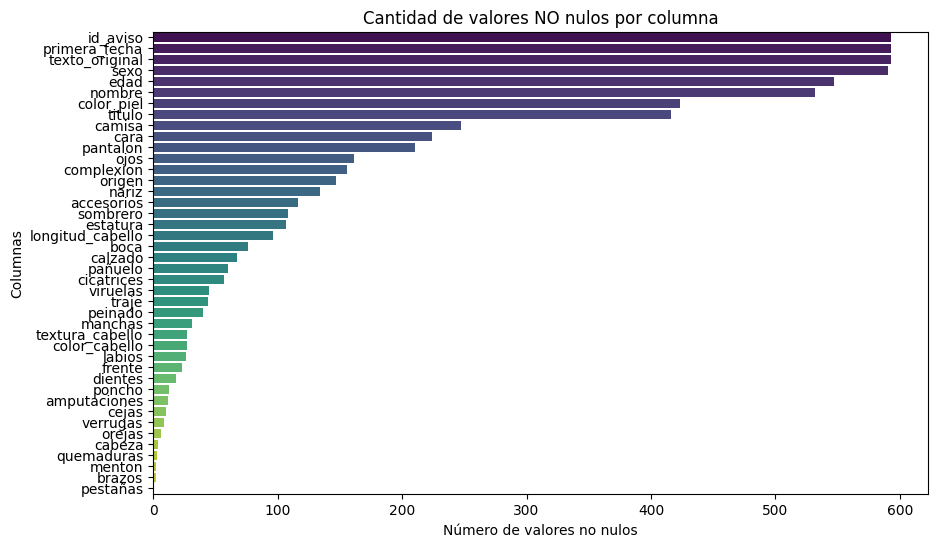

In [16]:
# Count non-null values per column
non_null_counts = df_avisos_cholitos.notnull().sum().sort_values(ascending=False)

# Display in sorted list
print("📊 Columnas ordenadas por cantidad de valores NO nulos:")
display(non_null_counts)

# Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    y=non_null_counts.index,
    x=non_null_counts.values,
    palette="viridis",
    hue=non_null_counts.index,
    legend=False,
)
plt.title("Number of Non-Null Values per Column")
plt.xlabel("Number of Non-Null Values")
plt.ylabel("Columns")
plt.show()

In [88]:
OUTPUT_PDF = "valores_columnas.pdf"
SUMMARY_ROWS_PER_PAGE = 25
FIGSIZE = (8.27, 11.69)  # A4
EXCLUIR = ["id_aviso", "primera_fecha", "texto_original"]

palette = sns.color_palette("deep")
HEADER_COLOR = palette[0]
ACCENT_COLOR = palette[2]
FONT = "DejaVu Sans Mono"

columnas_usar = [c for c in df_avisos_cholitos.columns if c not in EXCLUIR]

# --- Column summary ---
summary = pd.DataFrame(
    {
        "Columna": columnas_usar,
        "Tipo": [str(df_avisos_cholitos[c].dtype) for c in columnas_usar],
        "No nulos": [int(df_avisos_cholitos[c].notna().sum()) for c in columnas_usar],
        "Únicos": [
            int(df_avisos_cholitos[c].nunique(dropna=True)) for c in columnas_usar
        ],
    }
)
summary = summary.sort_values(by="No nulos", ascending=False).reset_index(drop=True)

with PdfPages(OUTPUT_PDF) as pdf:
    # --- Cover page ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_axis_off()
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="white"))
    ax.text(
        0.5,
        0.7,
        "Reporte de valores únicos",
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold",
        color=HEADER_COLOR,
        fontname=FONT,
    )
    ax.text(
        0.5,
        0.6,
        "Dataset: df_avisos_cholitos",
        ha="center",
        va="center",
        fontsize=16,
        color="black",
        fontname=FONT,
    )
    ax.text(
        0.5,
        0.5,
        f"Generado el {datetime.now().strftime('%d/%m/%Y %H:%M')}",
        ha="center",
        va="center",
        fontsize=12,
        color="gray",
        fontname=FONT,
    )
    ax.text(
        0.5,
        0.3,
        f"Columnas incluidas: {len(columnas_usar)}",
        ha="center",
        va="center",
        fontsize=12,
        color=ACCENT_COLOR,
        fontname=FONT,
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- General column summary ---
    total_summary_rows = len(summary)
    summary_pages = math.ceil(total_summary_rows / SUMMARY_ROWS_PER_PAGE) or 1
    for p in range(summary_pages):
        start = p * SUMMARY_ROWS_PER_PAGE
        end = start + SUMMARY_ROWS_PER_PAGE
        page_df = summary.iloc[start:end]

        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.set_axis_off()
        ax.add_patch(
            Rectangle((0, 0.92), 1, 0.07, transform=ax.transAxes, color=HEADER_COLOR)
        )
        ax.text(
            0.5,
            0.955,
            "Resumen general de columnas",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            color="white",
            fontname=FONT,
        )

        cell_text = page_df.values.tolist()
        col_labels = list(page_df.columns)
        table = ax.table(
            cellText=cell_text,
            colLabels=col_labels,
            cellLoc="left",
            loc="center",
            colLoc="left",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.2)
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_facecolor(HEADER_COLOR)
                cell.set_text_props(weight="bold", color="white", fontname=FONT)
            else:
                cell.set_facecolor("#fdfdfd" if row % 2 == 0 else "#f4f4f4")
                cell.set_text_props(fontname=FONT)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    # --- Unique values with frequencies ---
    total_cols = len(columnas_usar)
    for idx, col in enumerate(columnas_usar, start=1):
        vc = df_avisos_cholitos[col].dropna().value_counts()
        valores = sorted(vc.index.astype(str))  # alphabetical order

        wrapped_values = []
        for v in valores:
            freq = vc[v] if v in vc else 0
            text = f"{v}   ({freq})"
            wrapped = textwrap.wrap(text, width=80) or [""]
            wrapped_values.append(wrapped)

        line_height = 0.018
        y_start = 0.88
        y = y_start

        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.set_axis_off()
        ax.add_patch(
            Rectangle((0, 0.92), 1, 0.07, transform=ax.transAxes, color=HEADER_COLOR)
        )
        ax.text(
            0.01,
            0.955,
            f"Columna: {col}",
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="center",
            color="white",
            fontname=FONT,
        )
        ax.text(
            0.99,
            0.955,
            f"Tipo: {str(df_avisos_cholitos[col].dtype)}",
            transform=ax.transAxes,
            fontsize=9,
            ha="right",
            va="center",
            color="white",
            fontname=FONT,
        )
        ax.text(
            0.01,
            0.925,
            f"No nulos: {int(df_avisos_cholitos[col].notna().sum())}    Únicos: {int(df_avisos_cholitos[col].nunique(dropna=True))}",
            transform=ax.transAxes,
            fontsize=9,
            color="black",
            fontname=FONT,
        )

        for wrapped in wrapped_values:
            for line in wrapped:
                if y < 0.05:
                    pdf.savefig(fig, bbox_inches="tight")
                    plt.close(fig)
                    fig, ax = plt.subplots(figsize=FIGSIZE)
                    ax.set_axis_off()
                    y = y_start
                ax.text(
                    0.05,
                    y,
                    f"• {line}",
                    transform=ax.transAxes,
                    fontsize=8,
                    va="top",
                    fontname=FONT,
                )
                y -= line_height
            y -= line_height / 2

        ax.text(
            0.5,
            0.02,
            f"Columna {idx}/{total_cols}",
            ha="center",
            fontsize=8,
            color="gray",
            fontname=FONT,
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"✅ PDF creado: {OUTPUT_PDF}")

✅ PDF creado: valores_columnas.pdf


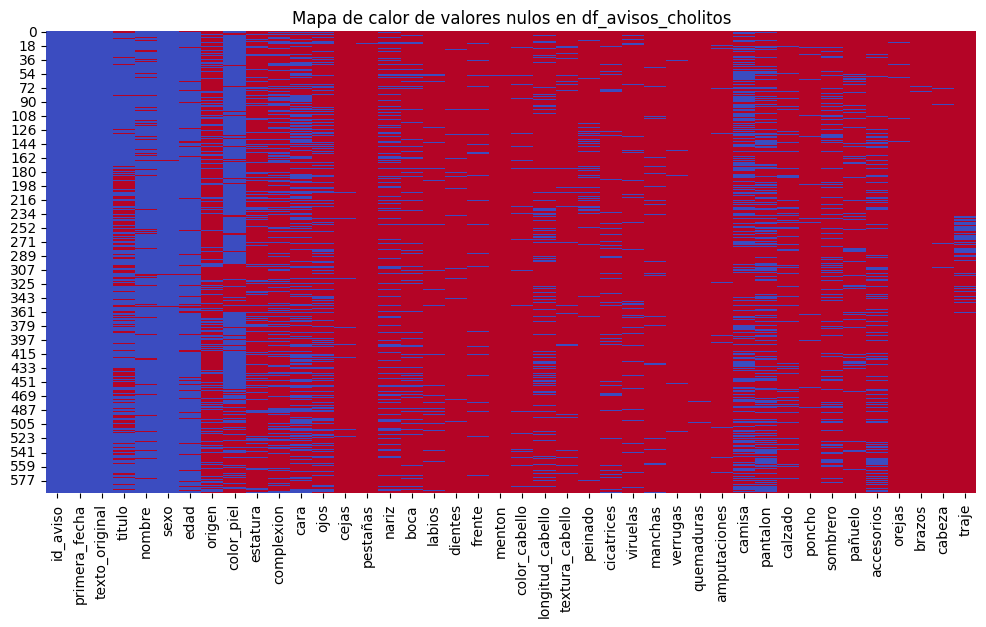

In [89]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_avisos_cholitos.isnull(), cbar=False, cmap="coolwarm")
plt.title("Heatmap of Null Values in df_avisos_cholitos")
plt.show()

## Creation of Macro-Groups by Column

In [17]:
# Creation of dictionaries.

edad_map = {
    "1 año y 10 meses": 1.83,
    "10": 10.0,
    "10 a 11": 10.5,
    "10 a 11 años": 10.5,
    "10 a 11 y 9 a 10 años": 10.25,
    "10 a 12": 11.0,
    "10 años": 10.0,
    "10 y 5 años": 10.5,
    "11": 11.0,
    "11 a 12": 11.5,
    "11 a 12 años": 11.5,
    "11 a 16 años de edad": 13.5,
    "11 años": 11.0,
    "11 y 10 años": 11.83,
    "12": 12.0,
    "12 a 13": 12.5,
    "12 a 13 años": 12.5,
    "12 a 14": 13.0,
    "12 años": 12.0,
    "13": 13.0,
    "13 a 14": 13.5,
    "13 a 14 años": 13.5,
    "13 años": 13.0,
    "13 años de edad": 13.0,
    "14": 14.0,
    "14 a 15": 14.5,
    "14 a 15 años": 14.5,
    "14 años": 14.0,
    "15": 15.0,
    "15 a 16": 15.5,
    "15 a 16 años": 15.5,
    "16": 16.0,
    "18": 18.0,
    "18 a 19": 18.5,
    "18 a 20 años": 19.0,
    "19": 19.0,
    "2 años": 2.0,
    "2 años 6 meses": 2.5,
    "20": 20.0,
    "3": 3.0,
    "4 a 5": 4.5,
    "5 a 6": 5.5,
    "5 años": 5.0,
    "5 para 6 años": 5.5,
    "50": 50.0,
    "6": 6.0,
    "6 a 7 años": 6.5,
    "6 a 8": 7.0,
    "6 años": 6.0,
    "7": 7.0,
    "7 a 8": 7.5,
    "7 a 8 años": 7.5,
    "7 años": 7.0,
    "7 años poco mas o menos": 7.0,
    "8": 8.0,
    "8 a 9": 8.5,
    "8 a 9 años": 8.5,
    "8 años": 8.0,
    "8 años para 9": 8.5,
    "8 o 9": 8.5,
    "9": 9.0,
    "9 a 10": 9.5,
    "9 a 10 años": 9.5,
    "9 años": 9.0,
    "año y 8 meses": 1.67,
    "año y medio": 1.5,
    "catorce a quince año": 14.5,
    "catorce años": 14.0,
    "cinco a nueve años": 7.0,
    "cinco a seis años": 5.5,
    "cinco años": 5.0,
    "como de ocho años": 8.0,
    "cuatro a cinco años": 4.5,
    "cuatro años": 4.0,
    "diecinueve años": 19.0,
    "dieciocho años": 18.0,
    "dieciseis años": 16.0,
    "diez a doce años de edad": 11.0,
    "diez a nueve años": 9.5,
    "diez a ocho años": 9.0,
    "diez a once años": 10.5,
    "diez a siete años": 8.5,
    "diez años": 10.0,
    "doce a catorce años": 13.0,
    "doce a once años": 11.5,
    "doce a trece años": 12.5,
    "doce años": 12.0,
    "doce años mas o menos": 12.0,
    "dos años": 2.0,
    "dos años de edad": 2.0,
    "edad de seis años": 6.0,
    "mayor de cuarenta años": 40.0,
    "mayor de diecisiete años doce años y ocho años": 12.33,
    "mayor de doce años": 13.0,
    "menor de edad": 17.0,
    "nueve a diez años": 9.5,
    "nueve a ocho años": 8.5,
    "nueve años": 9.0,
    "ocho a diez años": 9.0,
    "ocho a diez años de edad": 9.0,
    "ocho a nueve años": 8.5,
    "ocho a siete años": 7.5,
    "ocho años": 8.0,
    "once a diez años": 10.5,
    "once a doce años": 11.5,
    "once años": 11.0,
    "quince a catorce años": 14.5,
    "quince a catorce años y doce a once años": 13.0,
    "quince años": 15.0,
    "seis a cinco años": 5.5,
    "seis a siete años": 6.5,
    "siete a ocho años": 7.5,
    "siete a seis años": 6.5,
    "siete años": 7.0,
    "trece a catorce años": 13.5,
    "trece a doce años": 12.5,
    "trece años": 13.0,
    "tres años": 3.0,
    "tres años y meses": 3.0,
    "un año 8 meses": 1.67,
    "veinte a once años": 15.5,
    "veinte años": 20.0,
}

estatura_map = {
    # Tall / Large
    "alto": "Alto / Grande",
    "de estatura mas bien grande": "Alto / Grande",
    # Short / Small
    "algo pequeño": "Bajo / Pequeño",
    "baja": "Bajo / Pequeño",
    "baja de cuerpo": "Bajo / Pequeño",
    "bajo de cuerpo": "Bajo / Pequeño",
    "bajo de estatura": "Bajo / Pequeño",
    "chica de cuerpo": "Bajo / Pequeño",
    "chiquitito de cuerpo": "Bajo / Pequeño",
    "cuerpo pequeño": "Bajo / Pequeño",
    "estatura baja": "Bajo / Pequeño",
    "estatura baja de cinco pies a lo mas": "Bajo / Pequeño",
    "estatura media pequeño": "Bajo / Pequeño",
    "estatura pequeña": "Bajo / Pequeño",
    "estatura retaca": "Bajo / Pequeño",
    "juana es baja sebastiana es bajita pablo no dice": "Bajo / Pequeño",
    "muy pequeño de estatura": "Bajo / Pequeño",
    "pequeña": "Bajo / Pequeño",
    "pequeño": "Bajo / Pequeño",
    "pequeño de cuerpo": "Bajo / Pequeño",
    "petisa": "Bajo / Pequeño",
    "poca estatura": "Bajo / Pequeño",
    "retaco": "Bajo / Pequeño",
    "retacona": "Bajo / Pequeño",
    "talla chica": "Bajo / Pequeño",
    "tamaño pequeño": "Bajo / Pequeño",
    # Medium / Regular
    "estatura delgada": "Mediano / Regular",
    "estatura mediana": "Mediano / Regular",
    "estatura proporcionada": "Mediano / Regular",
    "estatura regular": "Mediano / Regular",
    "mediana estatura": "Mediano / Regular",
    "mediana estatura para su edad": "Mediano / Regular",
    "mediano para su edad": "Mediano / Regular",
    "regular": "Mediano / Regular",
    "regular tamaño": "Mediano / Regular",
    "tamaño regular": "Mediano / Regular",
    # Special / Numerical
    "5 y medio pies de alto": "Especial / Numérica",
    "cuatro pies y medio de alto": "Especial / Numérica",
    "su estatura la correspondiente": "Especial / Numérica",
    "vara y diez pulgadas mas o menos": "Especial / Numérica",
}

complexion_map = {
    # Thin / Slender
    "algo flaca": "Delgado / Flaco",
    "contestura delgada": "Delgado / Flaco",
    "cuerpo delgado": "Delgado / Flaco",
    "cuerpo delgado un poco flaca": "Delgado / Flaco",
    "cuerpo flaco": "Delgado / Flaco",
    "cuerpo pequeño y delgado": "Delgado / Flaco",
    "delgada": "Delgado / Flaco",
    "delgada de cuerpo": "Delgado / Flaco",
    "delgadita": "Delgado / Flaco",
    "delgado": "Delgado / Flaco",
    "muy delgado": "Delgado / Flaco",
    "muy flaca": "Delgado / Flaco",
    # Thick / Heavy / Robust
    "abultada": "Grueso / Gordo / Robusto",
    "algo grueso": "Grueso / Gordo / Robusto",
    "ancha de cuerpo": "Grueso / Gordo / Robusto",
    "barrigon": "Grueso / Gordo / Robusto",
    "bastante gorda": "Grueso / Gordo / Robusto",
    "berrigon rechoncho y cuadrado": "Grueso / Gordo / Robusto",
    "cachetona gorda barrigona": "Grueso / Gordo / Robusto",
    "cuerpo gordo": "Grueso / Gordo / Robusto",
    "de cuerpo grueso": "Grueso / Gordo / Robusto",
    "gorda": "Grueso / Gordo / Robusto",
    "gorda de cuerpo": "Grueso / Gordo / Robusto",
    "gorda pequeña un poco borrada": "Grueso / Gordo / Robusto",
    "gordete": "Grueso / Gordo / Robusto",
    "gordita": "Grueso / Gordo / Robusto",
    "gordito": "Grueso / Gordo / Robusto",
    "gordito y barrigon": "Grueso / Gordo / Robusto",
    "gordo": "Grueso / Gordo / Robusto",
    "gordo ancho de espaldas": "Grueso / Gordo / Robusto",
    "gordo chiquitito de cuerpo": "Grueso / Gordo / Robusto",
    "gordo retaco": "Grueso / Gordo / Robusto",
    "gruesa": "Grueso / Gordo / Robusto",
    "grueso": "Grueso / Gordo / Robusto",
    "juana es gorda sebastiana es muy gorda y pablo es muy gordo": "Grueso / Gordo / Robusto",
    "llena de carnes": "Grueso / Gordo / Robusto",
    "mas gorda que flaca": "Grueso / Gordo / Robusto",
    "metido en carnes": "Grueso / Gordo / Robusto",
    "muy gorda": "Grueso / Gordo / Robusto",
    "muy gordo": "Grueso / Gordo / Robusto",
    "regordete": "Grueso / Gordo / Robusto",
    "un poco gordo": "Grueso / Gordo / Robusto",
    "un poco gruesa": "Grueso / Gordo / Robusto",
    "bastante robusto": "Grueso / Gordo / Robusto",
    "gruesa y fornida de cuerpo": "Grueso / Gordo / Robusto",
    "mucho robustez gordo": "Grueso / Gordo / Robusto",
    "robusta": "Grueso / Gordo / Robusto",
    "robusto": "Grueso / Gordo / Robusto",
    # Small / Stocky
    "pequeña": "Pequeño / Retaco",
    "pequeña de cuerpo": "Pequeño / Retaco",
    "pequeña de cuerpo retacona": "Pequeño / Retaco",
    "pequeño": "Pequeño / Retaco",
    "pequeño de cuerpo y grueso": "Pequeño / Retaco",
    "pequeño muy gordo": "Pequeño / Retaco",
    "retaco": "Pequeño / Retaco",
    "retacona": "Pequeño / Retaco",
    "retaconcito": "Pequeño / Retaco",
    # Regular / Normal / Proportionate
    "cuerpo regular": "Regular / Normal / Proporcionado",
    "grueso regular": "Regular / Normal / Proporcionado",
    # Special / Descriptive
    "ancho de espaldas": "Especial / Descriptivo",
    "ancho de hombros": "Especial / Descriptivo",
    "bien parecida en su clase": "Especial / Descriptivo",
    "bien parecido": "Especial / Descriptivo",
    "borada": "Especial / Descriptivo",
    "borrado": "Especial / Descriptivo",
    "cargado de hombros": "Especial / Descriptivo",
    "corcobadita ancha y pequeña de cuerpo": "Especial / Descriptivo",
    "cuerpo mal formado": "Especial / Descriptivo",
    "delgado gordito": "Especial / Descriptivo",
    "gordo algo jibado": "Especial / Descriptivo",
    "gruesa y en dias de parir": "Especial / Descriptivo",
    "mano muy chica y bien formada": "Especial / Descriptivo",
    "media jibada": "Especial / Descriptivo",
    "patona": "Especial / Descriptivo",
}

cara_map = {
    # Geometric shape / structure
    "aguileña": "Forma geométrica / estructura",
    "ancha": "Forma geométrica / estructura",
    "buena caracara redonda": "Forma geométrica / estructura",
    "cabeza irregular": "Forma geométrica / estructura",
    "cabeza y cara larga y muy ceñida muy": "Forma geométrica / estructura",
    "cara abultada": "Forma geométrica / estructura",
    "cara aguileña": "Forma geométrica / estructura",
    "cara algo larga": "Forma geométrica / estructura",
    "cara ancha": "Forma geométrica / estructura",
    "cara chata": "Forma geométrica / estructura",
    "cara grande redonda": "Forma geométrica / estructura",
    "cara larga": "Forma geométrica / estructura",
    "cara llena": "Forma geométrica / estructura",
    "cara medio redonda": "Forma geométrica / estructura",
    "cara muy redonda": "Forma geométrica / estructura",
    "cara redonda": "Forma geométrica / estructura",
    "cara redonda encarañado": "Forma geométrica / estructura",
    "cara redonda grande": "Forma geométrica / estructura",
    "cariredondo": "Forma geométrica / estructura",
    "casi redonda": "Forma geométrica / estructura",
    "cuadrada": "Forma geométrica / estructura",
    "facciones aguileñas": "Forma geométrica / estructura",
    "larga": "Forma geométrica / estructura",
    "lleno de cara": "Forma geométrica / estructura",
    "redonda": "Forma geométrica / estructura",
    # Size / proportion
    "cabezon": "Tamaño / proporción",
    "cara grande": "Tamaño / proporción",
    "cara grande y cabezon": "Tamaño / proporción",
    "cara pequeña": "Tamaño / proporción",
    "caranton": "Tamaño / proporción",
    "caranton y cabezon": "Tamaño / proporción",
    "carentona": "Tamaño / proporción",
    "carigordo": "Tamaño / proporción",
    "gordo de cara": "Tamaño / proporción",
    "pequeña": "Tamaño / proporción",
    # Age / condition / appearance
    "cara y borrada": "Edad / estado / apariencia",
    "caranton y ajestado": "Edad / estado / apariencia",
    "juana tiene la cara tosca sebastiana es de buena cara y pablo no dice": "Edad / estado / apariencia",
    "revejida": "Edad / estado / apariencia",
    "revejido": "Edad / estado / apariencia",
    "revejido cuando se rie se le hacen ollos en el carillo": "Edad / estado / apariencia",
    # Aesthetic evaluation
    "bonito de cara": "Valoración estética",
    "buena cara": "Valoración estética",
    "buenas facciones": "Valoración estética",
    "cara bonita y colorada": "Valoración estética",
    "cara fea": "Valoración estética",
    "de bonita cara": "Valoración estética",
    "de buena cara": "Valoración estética",
    "facciones delicadas": "Valoración estética",
    "fea de rostro": "Valoración estética",
    "todas sus facciones muy finas": "Valoración estética",
    # Special features
    "al hablar se le manifiesta en la cara un hoyito en el carrillo derecho": "Rasgos especiales",
    "borracho cara redonda": "Rasgos especiales",
    "buena chaposo": "Rasgos especiales",
    "cara blanca y redonda pecosa": "Rasgos especiales",
    "cara de chino": "Rasgos especiales",
    "cara redonda grande tiene una señal en la cabeza como de tiña": "Rasgos especiales",
    "cara redonda y bien trigueña": "Rasgos especiales",
    "cara redondaalgo chapudito": "Rasgos especiales",
    "con bozo": "Rasgos especiales",
    "el pescuezo torcido para el lado derecho": "Rasgos especiales",
    # Regular / neutral
    "cara regular": "Regular / neutral",
    "regular": "Regular / neutral",
    # Mixed / dual classification
    "grande muy fea": "Tamaño / proporción + Valoración estética",
    "redonda facciones finas": "Forma geométrica / estructura + Valoración estética",
}

ojos_map = {
    # ------------------------------
    # Small
    # ------------------------------
    "chicos": "pequeños",
    "chiquitos": "pequeños",
    "de ojos chicos": "pequeños",
    "muy chicos y muy angosta": "pequeños",
    "ojos chicos": "pequeños",
    "ojos chicos pardos": "Mixta",
    "ojos chicos sin lagrimal": "pequeños",
    "ojos chicos y con un orzuelo en el izquierdo": "Mixta",
    "ojos chicos y vivos": "Mixta",
    "ojos encapotados chicos": "pequeños",
    "ojos estrechos": "pequeños",
    "ojos gachos que no los puede abrir bien": "pequeños",
    "ojos muy pequeños": "pequeños",
    "ojos pequeños": "pequeños",
    "ojos pequeños pardos": "Mixta",
    "ojos vivos y chicos": "Mixta",
    "pequeños": "pequeños",
    "pequeños encapotados": "pequeños",
    "pequeños y vivos": "Mixta",
    # ------------------------------
    # Large
    # ------------------------------
    "grandes": "grandes",
    "grandes y pardos": "Mixta",
    "ojos grandes": "grandes",
    "ojos grandes cegatones": "Mixta",
    "ojos grandes como de zamba": "grandes",
    "ojos grandes medios abobados": "grandes",
    "ojos grandes y expresivos": "Mixta",
    "ojos grandes y hundidos": "grandes",
    "ojos grandes y negros": "Mixta",
    "ojos idem y de expresion": "Mixta",
    "pardos grandes muy sombreados": "Mixta",
    "rasgados grandes": "Mixta",
    # ------------------------------
    # Black
    # ------------------------------
    "negros": "negros",
    "negros chicos": "Mixta",
    "negros grandes y casi redondos": "Mixta",
    "negros regulares": "Mixta",
    "ojos negros": "negros",
    "ojos negros chicos": "Mixta",
    "ojos negros encapotados": "Mixta",
    "ojos negros grandes": "Mixta",
    "ojos negros muy vivos": "Mixta",
    # ------------------------------
    # Brown / Dark
    # ------------------------------
    "ojos pardos": "pardos",
    "ojos pardos alegres": "Mixta",
    "ojos pardos pequeños": "Mixta",
    "ojos pardos regulares": "Mixta",
    "pardos": "pardos",
    "pardos pequeños": "Mixta",
    "pardos sin expresion": "Mixta",
    # ------------------------------
    # Light / Pale-eyed
    # ------------------------------
    "ojos sarcos": "azules / claros",
    "ojos azules y chicos": "Mixta",
    # ------------------------------
    # Expressive / Special shape
    # ------------------------------
    "ojos alegres": "expresivos / forma especial",
    "ojos algo hinchados": "expresivos / forma especial",
    "ojos medio encapotados": "expresivos / forma especial",
    "ojos muy vivos": "expresivos / forma especial",
    "ojos rasgados": "expresivos / forma especial",
    "ojos tienen semejanza en el cor a los de los chinos": "expresivos / forma especial",
    "ojos turbios": "expresivos / forma especial",
    "ojos turbios y tristones": "expresivos / forma especial",
    "parpados abultados": "expresivos / forma especial",
    "tiene unas negras bajo los ojos": "expresivos / forma especial",
    "vivos": "expresivos / forma especial",
    # ------------------------------
    # Ocular defect
    # ------------------------------
    "cegaton y tuerto": "defecto ocular",
    "en un ojo una especie de orzuelo y es algo legañocita": "defecto ocular",
    "los ojos siempre le estan llorando": "defecto ocular",
    "nube en el ojo": "defecto ocular",
    "nube en el ojo izquierdo": "defecto ocular",
    "ojo derecho fruncido": "defecto ocular",
    "ojo medio gacho": "defecto ocular",
    "ojos desiguales": "defecto ocular",
    "tuerta del ojo derecho": "defecto ocular",
    "tuerta del ojo izquierdo": "defecto ocular",
    "tuerto": "defecto ocular",
    "un lado del parpado del ojo caido": "defecto ocular",
    "un ojo tuerto": "defecto ocular",
    "un ojo visco": "defecto ocular",
    "una nube un ojo": "defecto ocular",
    "una nuve en el ojo izquierdo": "defecto ocular",
    "visojo": "defecto ocular",
    # ------------------------------
    # Regular
    # ------------------------------
    "ojos regulares": "regulares",
    "ojos regulares negros": "Mixta",
    "regulares": "regulares",
}

nariz_map = {
    # ------------------------------
    # Sharp / Pointed
    # ------------------------------
    "afilada": "Afilada",
    "nariz afilada": "Afilada",
    "nariz afilada y algo grande": "Mixta",
    "nariz bien grande y afilada": "Mixta",
    # ------------------------------
    # Aquiline
    # ------------------------------
    "aguileña": "Aguileña",
    "nariz aguileña": "Aguileña",
    # ------------------------------
    # Flat / Snub
    # ------------------------------
    "chata": "Chata",
    "nariz chata": "Chata",
    "nariz algo chata": "Chata",
    "nariz chata redonda": "Chata",
    "un poco chata": "Chata",
    # ------------------------------
    # Thin
    # ------------------------------
    "delgada": "Delgada",
    "nariz delgada": "Delgada",
    # ------------------------------
    # Large / Prominent
    # ------------------------------
    "medio narigon": "Grande / Narigona",
    "narigon": "Grande / Narigona",
    "naringona achatada": "Mixta",
    "nariz grande": "Grande / Narigona",
    "nariz grande y fea": "Mixta",
    "nariz idem": "Grande / Narigona",
    "nariz larga y ancha": "Grande / Narigona",
    "nariz muy abultada": "Grande / Narigona",
    "narizon": "Grande / Narigona",
    # ------------------------------
    # Regular / Normal
    # ------------------------------
    "nariz regular": "Regular / Normal",
    "regular": "Regular / Normal",
    # ------------------------------
    # Blunt / Rounded
    # ------------------------------
    "nariz roma": "Roma",
    "roma": "Roma",
    # ------------------------------
    # Snub / Pug
    # ------------------------------
    "medio ñato": "Ñata",
    "muy ñato": "Ñata",
    "nariz ancha media ñata": "Mixta",
    "nariz ñata": "Ñata",
    "poco ñata": "Ñata",
    "un poco ñato": "Ñata",
    "ñata": "Ñata",
    "ñata muy ñata": "Ñata",
    "ñatita": "Ñata",
    "ñatito": "Ñata",
    "ñato": "Ñata",
    "ñato azul": "Ñata",
    "ñato no mucho": "Ñata",
    # ------------------------------
    # Small
    # ------------------------------
    "nariz pequeña": "Pequeña",
    "pequeña": "Pequeña",
    # ------------------------------
    # With marks or distinctive details
    # ------------------------------
    "con una señal en la nariz": "Con señas o detalles",
    "nariz agachada": "Con señas o detalles",
    "nariz y boca": "Con señas o detalles",
    "nariz ancha": "Con señas o detalles",
}

boca_map = {
    # Large / Wide-mouthed
    "boca grande": "Grande / Bocona / Jetona / Hocicona",
    "boca grande gruesa": "Grande / Bocona / Jetona / Hocicona",
    "boca grande pronunciada": "Grande / Bocona / Jetona / Hocicona",
    "boca idem": "Grande / Bocona / Jetona / Hocicona",
    "bocona": "Grande / Bocona / Jetona / Hocicona",
    "grande": "Grande / Bocona / Jetona / Hocicona",
    "hocicona": "Grande / Bocona / Jetona / Hocicona",
    "jetona": "Grande / Bocona / Jetona / Hocicona",
    "abultada": "Grande / Bocona / Jetona / Hocicona",
    # Small
    "boca chica": "Pequeña / Chica",
    "boca chica el labio inferior grueso": "Pequeña / Chica",
    "boca pequeña": "Pequeña / Chica",
    "boca pequeña y gruesa": "Pequeña / Chica",
    "boca y chiquita afilada": "Pequeña / Chica",
    "chica": "Pequeña / Chica",
    "pequeña": "Pequeña / Chica",
    # Regular / Normal
    "boca regular": "Regular / Normal",
    "boca regular con un lugar frente a la nariz": "Regular / Normal",
    "boca regular dientes grandes y muy blancos": "Regular / Normal",
    "regular": "Regular / Normal",
    # With marks or distinctive details
    "las mandibulas bastante comprimidas que hacen una proyeccion hacia fuera semejando a una boca de cabra": "Con señas o detalles",
    "nariz y boca": "Con señas o detalles",
}

frente_map = {
    # Small
    "chica": "Chica / Pequeña",
    "frente chica": "Chica / Pequeña",
    "frente chica pero se le agranda cuando quiere rapandosela": "Chica / Pequeña",
    "frente chiquita": "Chica / Pequeña",
    "frente muy pequeña": "Chica / Pequeña",
    "frente pequeña": "Chica / Pequeña",
    "pequeña": "Chica / Pequeña",
    "muy chica y calzada": "Chica / Pequeña",
    # Low-set hairline
    "frente calzada": "Calzada",
    "frente calzada o con cabellos": "Calzada",
    "frente pequeña calzada": "Calzada",
    # Narrow / Recessed / Flat
    "frente estrecha": "Estrecha / Hundida / Chata",
    "frente hundida": "Estrecha / Hundida / Chata",
    "frente pequeña y chata": "Estrecha / Hundida / Chata",
    # With marks or distinctive details
    "en la coronilla de la cabeza tiene un empeine en forma de corona chiquita": "Con señas o detalles",
    "frente idem": "Con señas o detalles",
    "frente pequeña y cortados de ella": "Con señas o detalles",
    "señal en la frente": "Con señas o detalles",
}

longitud_cabello_map = {
    # Shaved / Bald / Hairless
    "cabeza pelada": "Pelona / Rapada / Sin pelo",
    "cabeza razurada": "Pelona / Rapada / Sin pelo",
    "la cabeza muy pelona": "Pelona / Rapada / Sin pelo",
    "muy pelona": "Pelona / Rapada / Sin pelo",
    "pelaconcita": "Pelona / Rapada / Sin pelo",
    "pelado": "Pelona / Rapada / Sin pelo",
    "pelado con raya": "Pelona / Rapada / Sin pelo",
    "pelona": "Pelona / Rapada / Sin pelo",
    "peloncito": "Pelona / Rapada / Sin pelo",
    "peloncito en la frente": "Pelona / Rapada / Sin pelo",
    "rapada a navaja": "Pelona / Rapada / Sin pelo",
    "rapada la cabeza": "Pelona / Rapada / Sin pelo",
    "recien pelado": "Pelona / Rapada / Sin pelo",
    "sin pelo alguno": "Pelona / Rapada / Sin pelo",
    "todo pelado": "Pelona / Rapada / Sin pelo",
    # Short / Cut / Trimmed
    "cortado": "Corto / Cortado / Recortado",
    "corto": "Corto / Cortado / Recortado",
    "pelo algo corto": "Corto / Cortado / Recortado",
    "pelo cortado": "Corto / Cortado / Recortado",
    "pelo cortado al tamaño de poco mas de un dedo": "Corto / Cortado / Recortado",
    "pelo corto": "Corto / Cortado / Recortado",
    "pelo corto color castaño": "Corto / Cortado / Recortado",
    "pelo corto que le llega al hombro": "Corto / Cortado / Recortado",
    "pelo corto y desigual": "Corto / Cortado / Recortado",
    "pelo mas corto que largo": "Corto / Cortado / Recortado",
    "pelo regular": "Corto / Cortado / Recortado",
    "recortado el pelo": "Corto / Cortado / Recortado",
    # Medium (shoulder-length, neck-length, intermediate)
    "a medio crecer": "Medio",
    "juana tiene el pelo al hombro sebastiana tiene el pelo al hombro y pablo tiene el pelo rebajado": "Medio",
    "llega al cuello": "Medio",
    # Long / Long braids
    "largo": "Largo / Trenzas largas",
    "pelo indio un poco largo": "Largo / Trenzas largas",
    "pelo largo": "Largo / Trenzas largas",
    "trenzas largas": "Largo / Trenzas largas",
    # Hair volume (thick, sparse, thin)
    "de mucho pelo": "Cantidad de pelo",
    "escaso de pelo": "Cantidad de pelo",
    "pelo abundante": "Cantidad de pelo",
    "poco pelo": "Cantidad de pelo",
    # With marks or distinctive details
    "cabeza de pelo rebajado o parejo": "Con señas o detalles",
}

peinado_map = {
    # Braids
    "cabello en dos trenzas largas": "Trenzas",
    "peinada de dos trenzas": "Trenzas",
    "peinado de trenzas": "Trenzas",
    "trenzas largas": "Trenzas",
    # Shaved / Bald
    "cabeza como pelona por delante": "Pelona / Rapada / Pelado",
    "pelado a navaja": "Pelona / Rapada / Pelado",
    "pelon": "Pelona / Rapada / Pelado",
    "pelona con el pelo hasta el pescuezo": "Pelona / Rapada / Pelado",
    "rapada": "Pelona / Rapada / Pelado",
    # Short / Very short / Rather short
    "pelo corto": "Corto / Muy corto / Más corto que largo",
    "pelo corto crespo": "Corto / Muy corto / Más corto que largo",
    "pelo mas corto que largo": "Corto / Muy corto / Más corto que largo",
    "pelo muy corto": "Corto / Muy corto / Más corto que largo",
    "pelo negro lacio y corto": "Corto / Muy corto / Más corto que largo",
    # Long / Loose
    "pelo largo": "Largo / Suelto",
    "pelo largo y un mechon cortado en la": "Largo / Suelto",
    "pelo suelto y sin taparse": "Largo / Suelto",
    # Straight / Curly
    "crespo ambareado": "Lacio / Crespo",
    "pelo lacio": "Lacio / Crespo",
    "pelo lacio negro y las puntas cortadas": "Lacio / Crespo",
    "pelo lacio y prieto": "Lacio / Crespo",
    # Hair volume
    "mucho pelo": "Cantidad de pelo",
    # Other / With marks or distinctive details
    "pelo": "Otros / Con señas o detalles",
    "peluquita": "Otros / Con señas o detalles",
    "recien peinado": "Otros / Con señas o detalles",
    "sin trenzas": "Otros / Con señas o detalles",
}

camisa_map = {
    # Shirt
    "algodon azul claro": "Camisa",
    "amotape": "Camisa",
    "bayeton azul": "Camisa",
    "camisa": "Camisa",
    "camisa aurora a listas": "Camisa",
    "camisa azul": "Camisa",
    "camisa azul de listado": "Camisa",
    "camisa azul de rayas oscuras": "Camisa",
    "camisa bengala rosada": "Camisa",
    "camisa blanca": "Camisa",
    "camisa blanca con morada": "Camisa",
    "camisa blanca floreada de azul": "Camisa",
    "camisa blanca sucia": "Camisa",
    "camisa blanca y camiseta color carne": "Camisa",
    "camisa color morada con rosado": "Camisa",
    "camisa color tierra": "Camisa",
    "camisa colorada": "Camisa",
    "camisa con listas": "Camisa",
    "camisa con listas azules": "Camisa",
    "camisa con pintas rosadas": "Camisa",
    "camisa de algo desteñida": "Camisa",
    "camisa de amotape": "Camisa",
    "camisa de bengala a pintas coloradas": "Camisa",
    "camisa de color": "Camisa",
    "camisa de color a listas": "Camisa",
    "camisa de color blanca con rayas moraditas": "Camisa",
    "camisa de color mmorado": "Camisa",
    "camisa de color olan morado de pla menudas camiseta de lustrin cabritilla": "Camisa",
    "camisa de color rosado": "Camisa",
    "camisa de cuadritos y un traje amarillo bastante sucio": "Camisa",
    "camisa de cuadros morados": "Camisa",
    "camisa de cuello volado": "Camisa",
    "camisa de franela morada a cuadritos": "Camisa",
    "camisa de lana grosella": "Camisa",
    "camisa de listadillo azul": "Camisa",
    "camisa de listado": "Camisa",
    "camisa de listado azul con blancochaqueton de paño azul": "Camisa",
    "camisa de listado nueva con botones de hueso en el pecho y cuello": "Camisa",
    "camisa de olan": "Camisa",
    "camisa de olan blanco con pintas moradas": "Camisa",
    "camisa de olan cabritilla": "Camisa",
    "camisa de olan colorado": "Camisa",
    "camisa de olan de color morado con blanco": "Camisa",
    "camisa de olan rosado con": "Camisa",
    "camisa de tis": "Camisa",
    "camisa de tocuyo": "Camisa",
    "camisa de tocuyo sucia": "Camisa",
    "camisa larga y un traje grande tambien de cambrai con flores verdes": "Camisa",
    "camisa morada": "Camisa",
    "camisa morada de cuello y manga larga": "Camisa",
    "camisa rosada": "Camisa",
    "camisa rosada de olan": "Camisa",
    "camisa rosado y blanco": "Camisa",
    # Blouse / Small shirt
    "blusa de lana y seda verde a cuadros": "Blusa",
    "blusa saco de casimir fondo azul con cordones negros": "Blusa",
    "bluza de genero de li celeste": "Blusa",
    "camisita morada desteñida": "Camisita",
    "camisita morada traje de cambrai aurora": "Camisita",
    # Nightshirt / Smock
    "camison de coco y traje de olan a listas blancas y coloradas": "Camison",
    "camison de coco y un traje con cuello de olan cafe de listas con flores": "Camison",
    "camison y traje de olan": "Camison",
    # Jacket / Coat / Heavy jacket / Short jacket / Frock
    "chamarra azul": "Chaqueta",
    "chamarra fondo blanco con cuadritos negros": "Chaqueta",
    "chaqueta azul": "Chaqueta",
    "chaqueta color mezclilla de algodon": "Chaqueta",
    "chaqueta color plomo": "Chaqueta",
    "chaqueta de cubica azul": "Chaqueta",
    "chaqueta de jenero de algodon auroracamisa de algodon rosada": "Chaqueta",
    "chaqueta de jenero de algodon azul": "Chaqueta",
    "chaqueta de listas oscura todo nuevo camisa morada con blanco": "Chaqueta",
    "chaqueta de pana verde": "Chaqueta",
    "chaqueta de paño color concho de vino": "Chaqueta",
    "chaqueta de piel plomocamisa blanca con bastones": "Chaqueta",
    "chaqueta mezclilla de manquin camisa de tocuyo": "Chaqueta",
    "chaqueton azul camisa de listadillo rosada muy rota": "Chaqueta",
    "chaqueton blanco": "Chaqueta",
    "chaqueton de jenero azul asargado camisa de olan a cuadritos": "Chaqueta",
    "chaqueton de listado azul": "Chaqueta",
    "chaqueton de mezclilla": "Chaqueta",
    "chaqueton verde obscuro": "Chaqueta",
    "cotona azul": "Chaqueta",
    "saco color cabritilla de florecitas con mangas cortas": "Chaqueta",
    "saco de lana a cuadros": "Chaqueta",
    "saquito aurora": "Chaqueta",
    "saquito de merino": "Chaqueta",
    # Frock coat
    "levita de cubica negra": "Levita",
    "levita negra de paño": "Levita",
    "levita negra y rota por el brazo": "Levita",
    # Shirt sleeves / In shirt sleeves
    "en mangas de camisa": "Mangas de camisa",
    "en mangas de camisa de olan morado": "Mangas de camisa",
    "juana y sebastiana llevan un traje de merino negro y pablo mangas de camisa": "Mangas de camisa",
    "mangas de camisa": "Mangas de camisa",
    "mangas de camisa de elan rosado": "Mangas de camisa",
    "mangas de camisa de mandapolan": "Mangas de camisa",
    # Suit / Outfit
    "trage amarillo oscuro": "Traje",
    "trage de lana morado": "Traje",
    "trage de olan blanco con morado": "Traje",
    "trage de olan plomo otro de seda negro": "Traje",
    "trage de olan rosado": "Traje",
    "tragecito color rosado": "Traje",
    "traje a cabritilla a cuadros": "Traje",
    "traje azul": "Traje",
    "traje color amarillo y menta negra": "Traje",
    "traje color cafe": "Traje",
    "traje color mahon con estrellitas negras": "Traje",
    "traje de cabritilla": "Traje",
    "traje de cambray color morado con ramas": "Traje",
    "traje de cambray color morado con ramason menuda blanca": "Traje",
    "traje de cambray morado": "Traje",
    "traje de cambray rosado con blanco": "Traje",
    "traje de car color rosado y verde": "Traje",
    "traje de carlacan a cuadros": "Traje",
    "traje de color morado": "Traje",
    "traje de color morado muy sucio": "Traje",
    "traje de color y flores azules": "Traje",
    "traje de elan": "Traje",
    "traje de lana color morado": "Traje",
    "traje de lana plomo con flores azules": "Traje",
    "traje de m plomo labrado": "Traje",
    "traje de merino color jacinto": "Traje",
    "traje de merino negro con listadillos blanco": "Traje",
    "traje de merino verde": "Traje",
    "traje de olan a listas cafe y azul sombreado con negro a eslabones enredados": "Traje",
    "traje de olan colorado": "Traje",
    "traje de olan de cuadros menudos morado": "Traje",
    "traje de olan de listas": "Traje",
    "traje de olan desteñido con listas verdes": "Traje",
    "traje de olan fondo blanco descolorido": "Traje",
    "traje de olan morado con blanco": "Traje",
    "traje de olan morado con culebritas de colores camisa de tocuyo con cuello": "Traje",
    "traje de percala color cabritilla labor menuda": "Traje",
    "traje de percala jaspeado negro con amarillo": "Traje",
    "traje de percala mahon con listas negras": "Traje",
    "traje de terciopelo cabritilla viejo": "Traje",
    "traje de velo claro": "Traje",
    "traje morado de olan con unos tronquitos negros": "Traje",
    "traje que llevaba es de barragan cabritilla": "Traje",
    "traje rosado": "Traje",
    "traje rosado con blanco": "Traje",
    "traje rosado con plomo a": "Traje",
    "traje rosado de dos bobos ribeteado con una cinta negra": "Traje",
    "traje rosado de olas": "Traje",
    "traje verde con blanco": "Traje",
    "traje verde con negro": "Traje",
    "traje verde de barragan de cuadritos un delantal del mismo jenero con una tira de merino azul": "Traje",
    "trajecito claro": "Traje",
    "trajecito de cabritilla": "Traje",
    "trajecito de lana con cuadros morados con verde": "Traje",
    "trajecito de lanilla con fondo cabritilla": "Traje",
    "trajecito de olan": "Traje",
    "trajecito de olan cabritilla claro camisa de listadito azul": "Traje",
    "trajecito de olan de color y su": "Traje",
    "trajecito de olan oscuro de cuadros": "Traje",
    "trajecito de tartan de lana oscura a cuadros": "Traje",
    "trajecito verde": "Traje",
    # Dress / Attire
    "vestida con traje aurora": "Vestido",
    "vestida con traje y saco de olan amarillo": "Vestido",
    "vestida de luto": "Vestido",
    "vestida de negro y pañuelon de vapor bordado": "Vestido",
    "vestido": "Vestido",
    "vestido azul": "Vestido",
    "vestido azul y camisa color morada con blanco": "Vestido",
    "vestido celeste de panilla": "Vestido",
    "vestido claro": "Vestido",
    "vestido completo de paño azul": "Vestido",
    "vestido con un trajesito color obscuro": "Vestido",
    "vestido de blanco sucio": "Vestido",
    "vestido de brillantina amarillo": "Vestido",
    "vestido de colin azul": "Vestido",
    "vestido de cordellate con poncho azul de castilla": "Vestido",
    "vestido de genero de algodon azul con negro": "Vestido",
    "vestido de genero de cuadros color morado": "Vestido",
    "vestido de jenero azul": "Vestido",
    "vestido de nuevo": "Vestido",
    "vestido de servicio": "Vestido",
    "vestido plomo descolorido": "Vestido",
    "vestido sencillo rosado y blanco": "Vestido",
    "vestido traje de olan": "Vestido",
    "vestidos de seda y de lana": "Vestido",
    "vestuario color morado cabritilla y rosado blanco": "Vestido",
    # Tunic / Tuin
    "tuin": "Tuin",
    "tuin de": "Tuin",
    "tuin de lustrin negro": "Tuin",
    "tuin negro": "Tuin",
    "tuy de dril aplomado": "Tuin",
    # Fabric / Cloth / Garments
    "genero azul": "Género / Tela",
    "genero de algodon rayado": "Género / Tela",
    "ropa de panilla camisa blanca con pintas moradas": "Género / Tela",
    "ropa oscura": "Género / Tela",
    "su vetsido es de genero de listas": "Género / Tela",
    "tela sencilla": "Género / Tela",
    "pollera de lana color morado desteñido": "Género / Tela",
    # Other
    "casimir": "Otros",
    "de servicio": "Otros",
}

pantalon_map = {
    # Blue
    "algodon azul claro": "Azul",
    "calzon azul": "Azul",
    "calzon de sarga azul": "Azul",
    "calzon jacinto": "Azul",
    "calzoncito azul": "Azul",
    "genero azul": "Azul",
    "pantalon azul": "Azul",
    "pantalon azul de algodon": "Azul",
    "pantalon azul de casimir": "Azul",
    "pantalon azul de cuadritos": "Azul",
    "pantalon azul de cuadros blancos": "Azul",
    "pantalon azul de listas": "Azul",
    "pantalon azul de paño": "Azul",
    "pantalon azul rayado ya viejo": "Azul",
    "pantalon azul usado": "Azul",
    "pantalon azul viejo de pavo": "Azul",
    "pantalon de algodon azul": "Azul",
    "pantalon de bayeton azul": "Azul",
    "pantalon de casimir azul": "Azul",
    "pantalon de casimir azul con rayas negras": "Azul",
    "pantalon de genero azul": "Azul",
    "pantalon de genero de listas azules": "Azul",
    "pantalon de listado azul": "Azul",
    "pantalon de paño azul": "Azul",
    "pantalon de paño azul chico ajustado y roto": "Azul",
    "pantalon de los mismo (si es azul por contexto)": "Azul",
    "pantalon de dril azul con blancas": "Azul",
    "del mismo genero de algodon azul con cuadros descoloridos": "Azul",
    "vestido de genero de algodon azul con negro": "Azul",
    # White
    "calzon de brin blanco": "Blanco",
    "calzoncito de blan": "Blanco",
    "calzoncito de olan blanco con cuadros cabritilla": "Blanco",
    "pantalon blanco": "Blanco",
    "pantalon blanco listado": "Blanco",
    "pantalon de brin blanco": "Blanco",
    "pantalon de choleta blanco de hilo": "Blanco",
    # Black
    "calzon de algodon color negro": "Negro",
    "pantalon de casinete negro con listas blancas": "Negro",
    "pantalon de pana negro forrado en tocuyo": "Negro",
    "pantalon de paño negro": "Negro",
    "pantalon de negro de lana": "Negro",
    "pantalon negro": "Negro",
    "pantalon negro con listas blancas": "Negro",
    "pantalon negro de paño viejo": "Negro",
    "pantalon de seda negra en cabritilla": "Negro",
    "traje de percala jaspeado negro con amarillo": "Negro",
    # Lead / Gray
    "calzon plomo": "Plomo / Gris",
    "pantalon color plomo": "Plomo / Gris",
    "pantalon de casimir gris": "Plomo / Gris",
    "pantalon de casimir plomo": "Plomo / Gris",
    "pantalon de drill color plomo": "Plomo / Gris",
    "pantalon de paño color plomo": "Plomo / Gris",
    "pantalon de piel plomo": "Plomo / Gris",
    "pantalon plomo": "Plomo / Gris",
    "pantalon plomo con cuadritos negros": "Plomo / Gris",
    "pantalon plomo con listas": "Plomo / Gris",
    "pantalon lo mismo color gris rayado": "Plomo / Gris",
    # Brown
    "cafe": "Café / Marrón",
    "calzon de paño oscuro (si refiere café/oscuro)": "Café / Marrón",
    "pantalon de bayeta de color cafe": "Café / Marrón",
    "pantalon casi de color avellana": "Café / Marrón",
    "cascara almendra": "Café / Marrón",
    # Green
    "pantalon de casimir de cuadros color verde": "Verde",
    "pantalon de casimir fondo azul con cabritilla y cuadros verdes": "Verde",
    "pantalon de paño verde oscuro": "Verde",
    "pantalon verde": "Verde",
    "pantalon verde aceituna de paño": "Verde",
    "pantalon verde oscuro": "Verde",
    # Purple
    "pantalon morado": "Morado",
    "traje de color morado": "Morado",
    "traje de color morado muy sucio": "Morado",
    "traje de lana color morado": "Morado",
    "traje de olan morado": "Morado",
    "vesito de genero de cuadros color morado": "Morado",
    # Dark (generic)
    "calzon oscuro": "Oscuro (genérico)",
    "pantalon de casimir color oscuro": "Oscuro (genérico)",
    "pantalon de genero oscuro": "Oscuro (genérico)",
    "pantalon oscuro": "Oscuro (genérico)",
    "pantalon oscuro de casimir": "Oscuro (genérico)",
    "pantalon de sierra cabritilla oscuro": "Oscuro (genérico)",
    # Light (generic)
    "pantalon claro": "Claro (genérico)",
    "pantalon claro de listas": "Claro (genérico)",
    "pantalon de casimir claro": "Claro (genérico)",
    "pantalon de flor romero": "Claro (genérico)",
    "trajecito claro": "Claro (genérico)",
    "traje de velo claro": "Claro (genérico)",
    # Striped / Checked / Plaid
    "calzon de azules y jenero de color": "Rayado / Listado / Cuadros",
    "genero de algodon rayado": "Rayado / Listado / Cuadros",
    "listas pantalon de casimir": "Rayado / Listado / Cuadros",
    "pantalon a cuadros de dril de algodon colores medio blancos": "Rayado / Listado / Cuadros",
    "pantalon a cuadros vestido de servicio": "Rayado / Listado / Cuadros",
    "pantalon a listas de manquin": "Rayado / Listado / Cuadros",
    "pantalon azul de cuadritos": "Rayado / Listado / Cuadros",
    "pantalon azul de cuadros blancos": "Rayado / Listado / Cuadros",
    "pantalon azul de listas": "Rayado / Listado / Cuadros",
    "pantalon cabritilla de cuadros azules": "Rayado / Listado / Cuadros",
    "pantalon de casimir a cuadros": "Rayado / Listado / Cuadros",
    "pantalon de casimir a cuadros blancos": "Rayado / Listado / Cuadros",
    "pantalon de casimir rayado": "Rayado / Listado / Cuadros",
    "pantalon de cuadros": "Rayado / Listado / Cuadros",
    "pantalon de cuadros menudos": "Rayado / Listado / Cuadros",
    "pantalon de cuadros oscuros": "Rayado / Listado / Cuadros",
    "pantalon de cuadros pequeños": "Rayado / Listado / Cuadros",
    "pantalon de dril de listas": "Rayado / Listado / Cuadros",
    "pantalon de dril listado": "Rayado / Listado / Cuadros",
    "pantalon de genero con listitas azules y blancas": "Rayado / Listado / Cuadros",
    "pantalon de genero de cuadro oscuro": "Rayado / Listado / Cuadros",
    "pantalon de jenero de listas": "Rayado / Listado / Cuadros",
    "pantalon de listas": "Rayado / Listado / Cuadros",
    "pantalon plomo con cuadritos negros": "Rayado / Listado / Cuadros",
    "pantalon plomo con listas": "Rayado / Listado / Cuadros",
    # Cotton / Coarse canvas / Drill / Denim
    "calzon de brin blanco": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de algodon a cuadros": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de algodon de cuadritos negros y blancos": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de casimir de algodon": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de dril de amotape": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de dril puereo": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de dril listado": "Algodón / Brin / Dril / Mezclilla",
    "pantalon dril plomo de algodon": "Algodón / Brin / Dril / Mezclilla",
    "pantalon de mezclilla": "Algodón / Brin / Dril / Mezclilla",
    # Cashmere / Wool cloth / Wool / Silk / Cordellate
    "pantalon de casimir doble": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de casimir fondo azul con cabritilla y cuadros verdes": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de casimir oscuro con franja": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de paño": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de paño azul": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de paño negro": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de paño verde oscuro": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de cordellate color cabritilla": "Casimir / Paño / Lana / Seda / Cordellate",
    "pantalon de lana (mencionados en negros)": "Casimir / Paño / Lana / Seda / Cordellate",
    # Kidskin
    "pantalon cabritilla de medio paño": "Cabritilla",
    "pantalon de puño cabritilla ancho": "Cabritilla",
    "pantalon de sierra cabritilla oscuro": "Cabritilla",
    "pantalon de seda negra en cabritilla": "Cabritilla",
    # Amotape / Chohe / Choleta / Macedonia (traditional textiles)
    "amotape": "Amotape / Chohe / Choleta / Macedonia",
    "pantalon de dril de amotape": "Amotape / Chohe / Choleta / Macedonia",
    "pantalon de chohe": "Amotape / Chohe / Choleta / Macedonia",
    "pantalon de choleta blanco de hilo": "Amotape / Chohe / Choleta / Macedonia",
    "pantalon de macedonia": "Amotape / Chohe / Choleta / Macedonia",
    # Torn / Old / Worn
    "calzon roto": "Roto / Viejo / Usado",
    "pantalon azul rayado ya viejo": "Roto / Viejo / Usado",
    "pantalon azul usado": "Roto / Viejo / Usado",
    "pantalon azul viejo de pavo": "Roto / Viejo / Usado",
    "pantalon negro de paño viejo": "Roto / Viejo / Usado",
    "pantalon de paño azul chico ajustado y roto": "Roto / Viejo / Usado",
    # Service attire / Uniform
    "de servicio": "De servicio / Uniforme",
    "pantalon a cuadros vestido de servicio": "De servicio / Uniforme",
    # Suits / Dresses / Non-trouser clothing
    "ropa oscura": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje a cabritilla a cuadros": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de color morado": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de color morado muy sucio": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de lana color morado": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de olan morado": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de percala jaspeado negro con amarillo": "Trajes / Vestidos / Ropa distinta al pantalón",
    "traje de velo claro": "Trajes / Vestidos / Ropa distinta al pantalón",
    "trajecito claro": "Trajes / Vestidos / Ropa distinta al pantalón",
    "vesito de genero de cuadros color morado": "Trajes / Vestidos / Ropa distinta al pantalón",
    "vestido de genero de algodon azul con negro": "Trajes / Vestidos / Ropa distinta al pantalón",
    # Other / Undefined
    "pantalon (genérico)": "Otros / Indefinidos",
    "pantalon de (incompleto)": "Otros / Indefinidos",
    "pantalon id de casimir": "Otros / Indefinidos",
    "pantalon de lo mismo color gris rayado (si dudoso)": "Otros / Indefinidos",
    "pablo lleva pantalon de color": "Otros / Indefinidos",
    # Without trousers
    "sin pantalon": "Sin pantalón",
}

color_piel_map = {
    # Indigenous
    "casta indijena": "Indígena",
    "casta indio": "Indígena",
    "cholita india clara": "Indígena",
    "color indijena": "Indígena",
    "color indio": "Indígena",
    "cholito color india prieta": "Indígena",
    "color indio prieto": "Indígena",
    "es indio y que mas se asemeja a zambo": "Indígena",
    "india": "Indígena",
    "indicio": "Indígena",
    "indigena": "Indígena",
    "indigena claro": "Indígena",
    "indigena de color claro": "Indígena",
    "indijena": "Indígena",
    "indio": "Indígena",
    "indio blanco": "Indígena",
    "indio cholo": "Indígena",
    "indio mestizo": "Indígena",
    "juana es india clara y pablo indio negro": "Indígena",
    # White / Fair-skinned
    "blanca": "Blancos/Claros",
    "blanco rosado": "Blancos/Claros",
    "color algo claro": "Blancos/Claros",
    "color blanco": "Blancos/Claros",
    "color claro": "Blancos/Claros",
    "pálido": "Blancos/Claros",
    # Regional / Territorial origin
    "cholita serrana trigueña": "Territorial",
    "cholito jaujino": "Territorial",
    "serranito": "Territorial",
    # Cholos / Chinas
    "casta china chola": "Cholos/Chinas",
    "casta cholita": "Cholos/Chinas",
    "casta cholo": "Cholos/Chinas",
    "china chola": "Cholos/Chinas",
    "chola": "Cholos/Chinas",
    "cholita": "Cholos/Chinas",
    "cholito": "Cholos/Chinas",
    "cholito borrado (¿?)": "Cholos/Chinas",
    "cholo": "Cholos/Chinas",
    "cholo palido": "Cholos/Chinas",
    "color chino": "Cholos/Chinas",
    "color cholita": "Cholos/Chinas",
    "color cholito": "Cholos/Chinas",
    "color cholo claro": "Cholos/Chinas",
    "china chola blanca": "Cholos/Chinas",
    "cholita color algo claro": "Cholos/Chinas",
    # Wheat-toned / Sun-tanned
    "chola trigueña": "Trigueños/Tostados",
    "cholita muy tostada": "Trigueños/Tostados",
    "cholito color trigueño": "Trigueños/Tostados",
    "cobruna": "Trigueños/Tostados",
    "color cobruno": "Trigueños/Tostados",
    "color de mate": "Trigueños/Tostados",
    "color tostado": "Trigueños/Tostados",
    "color trigueño": "Trigueños/Tostados",
    "color trigueño rosado": "Trigueños/Tostados",
    "color trigueño y algo quemado del camino": "Trigueños/Tostados",
    "colorado": "Trigueños/Tostados",
    "muy trigueña": "Trigueños/Tostados",
    "trigueña": "Trigueños/Tostados",
    "trigueño": "Trigueños/Tostados",
    "trigueño mestizo": "Trigueños/Tostados",
    # Peruvian
    "cholito color peruano prieto": "Peruanos",
    "cholo peruano": "Peruanos",
    "color peruano": "Peruanos",
    "peruanita": "Peruanos",
    "peruanito": "Peruanos",
    "peruano": "Peruanos",
    # Yellow / Yellowish
    "color amarillento": "Amarillo/Amarillento",
    "tez es muy amarilla": "Amarillo/Amarillento",
    # Brown / Dark / Mulatto
    "amulatado": "Pardos/Prietos/Mulatos",
    "cholita color prieto": "Pardos/Prietos/Mulatos",
    "cholito color moreno": "Pardos/Prietos/Mulatos",
    "color china prieta": "Pardos/Prietos/Mulatos",
    "color moreno subido": "Pardos/Prietos/Mulatos",
    "color negro": "Pardos/Prietos/Mulatos",
    "color pardo": "Pardos/Prietos/Mulatos",
    "color prieto": "Pardos/Prietos/Mulatos",
    "prieto": "Pardos/Prietos/Mulatos",
    "zambo cholo": "Pardos/Prietos/Mulatos",
    # Mestizo
    "casta mestiza india": "Mestizos",
    "casta mestizo": "Mestizos",
    "cholito color mestizo": "Mestizos",
    "cholito mestizo": "Mestizos",
    "cholito mestizo blanco": "Mestizos",
    "color mesticita": "Mestizos",
    "color mestizo": "Mestizos",
    "color mestizo claro": "Mestizos",
    "sebastiana es mestiza": "Mestizos",
    "media mestiza": "Mestizos",
    "mesticita": "Mestizos",
    "mesticito": "Mestizos",
    "mestiza": "Mestizos",
    "mestiza clara": "Mestizos",
    "mestiza serrana": "Mestizos",
    "mestizo": "Mestizos",
    "mestizo blanco": "Mestizos",
    "mestizo claro": "Mestizos",
    "mestizo quarteron": "Mestizos",
}

In [18]:
# Application of dictionaries.

df_avisos_cholitos['edad_num'] = df_avisos_cholitos['edad'].map(edad_map).fillna("Sin clasificar")
df_avisos_cholitos['estatura_macro'] = df_avisos_cholitos['estatura'].map(estatura_map).fillna("Sin clasificar")
df_avisos_cholitos['complexion_macro'] = df_avisos_cholitos['complexion'].map(complexion_map).fillna("Sin clasificar")
df_avisos_cholitos['cara_macro'] = df_avisos_cholitos['cara'].map(cara_map).fillna("Sin clasificar")
df_avisos_cholitos['ojos_macro'] = df_avisos_cholitos['ojos'].map(ojos_map).fillna("Sin clasificar")
df_avisos_cholitos['nariz_macro'] = df_avisos_cholitos['nariz'].map(nariz_map).fillna("Sin clasificar")
df_avisos_cholitos['boca_macro'] = df_avisos_cholitos['boca'].map(boca_map).fillna("Sin clasificar")
df_avisos_cholitos['frente_macro'] = df_avisos_cholitos['frente'].map(frente_map).fillna("Sin clasificar")
df_avisos_cholitos['longitud_cabello_macro'] = df_avisos_cholitos['longitud_cabello'].map(longitud_cabello_map).fillna("Sin clasificar")
df_avisos_cholitos['peinado_macro'] = df_avisos_cholitos['peinado'].map(peinado_map).fillna("Sin clasificar")
df_avisos_cholitos['camisa_macro'] = df_avisos_cholitos['camisa'].map(camisa_map).fillna("Sin clasificar")
df_avisos_cholitos['pantalon_macro'] = df_avisos_cholitos['pantalon'].map(pantalon_map).fillna("Sin clasificar")
df_avisos_cholitos['color_piel_macro'] = df_avisos_cholitos['color_piel'].map(color_piel_map).fillna("Sin clasificar")

Distribución de la columna 'edad_num' sin 'Sin clasificar':
edad_num
10.0     9.944751
12.0     9.760589
13.0     6.261510
9.5      6.077348
11.5     6.077348
11.0     5.709024
7.0      5.156538
10.5     5.156538
9.0      4.972376
8.0      4.604052
14.0     4.604052
12.5     4.235727
8.5      3.867403
13.5     3.499079
7.5      3.130755
6.0      2.209945
14.5     2.025783
6.5      1.473297
15.5     1.104972
15.0     1.104972
5.0      1.104972
2.0      0.920810
5.5      0.920810
3.0      0.736648
4.5      0.552486
16.0     0.552486
18.0     0.552486
19.0     0.552486
4.0      0.368324
2.5      0.368324
20.0     0.368324
1.67     0.368324
17.0     0.184162
50.0     0.184162
18.5     0.184162
1.83     0.184162
10.25    0.184162
40.0     0.184162
11.83    0.184162
1.5      0.184162
12.33    0.184162
Name: proportion, dtype: float64




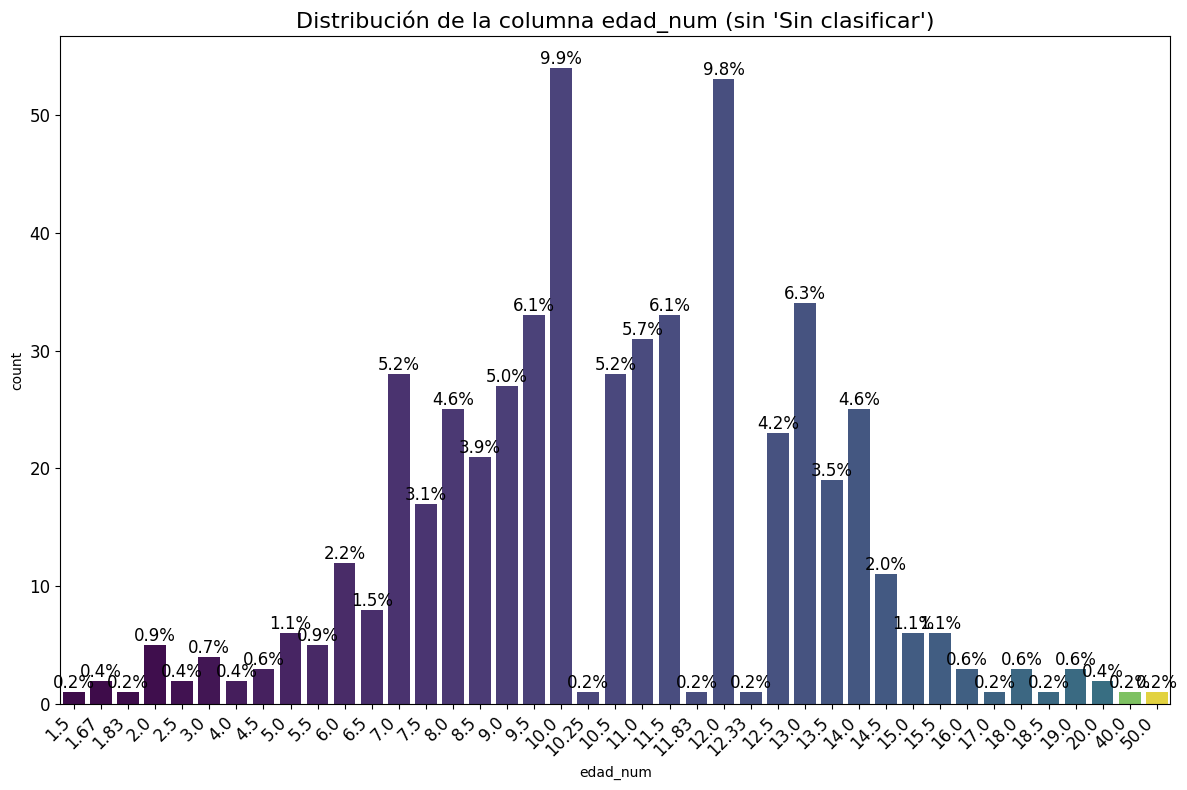

Distribución de la columna 'estatura_macro' sin 'Sin clasificar':
estatura_macro
Bajo / Pequeño         71.8750
Mediano / Regular      23.4375
Especial / Numérica     3.1250
Alto / Grande           1.5625
Name: proportion, dtype: float64




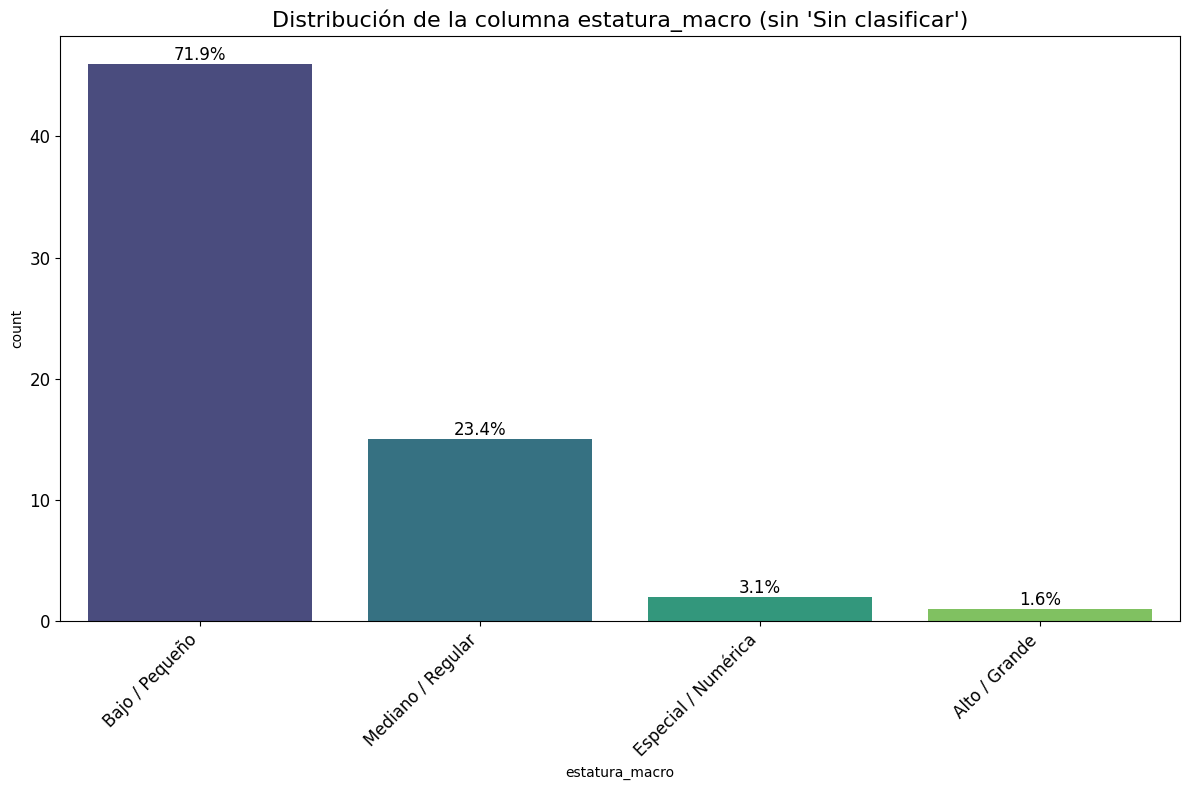

Distribución de la columna 'complexion_macro' sin 'Sin clasificar':
complexion_macro
Grueso / Gordo / Robusto            58.695652
Delgado / Flaco                     18.478261
Especial / Descriptivo              11.956522
Pequeño / Retaco                     6.521739
Regular / Normal / Proporcionado     4.347826
Name: proportion, dtype: float64




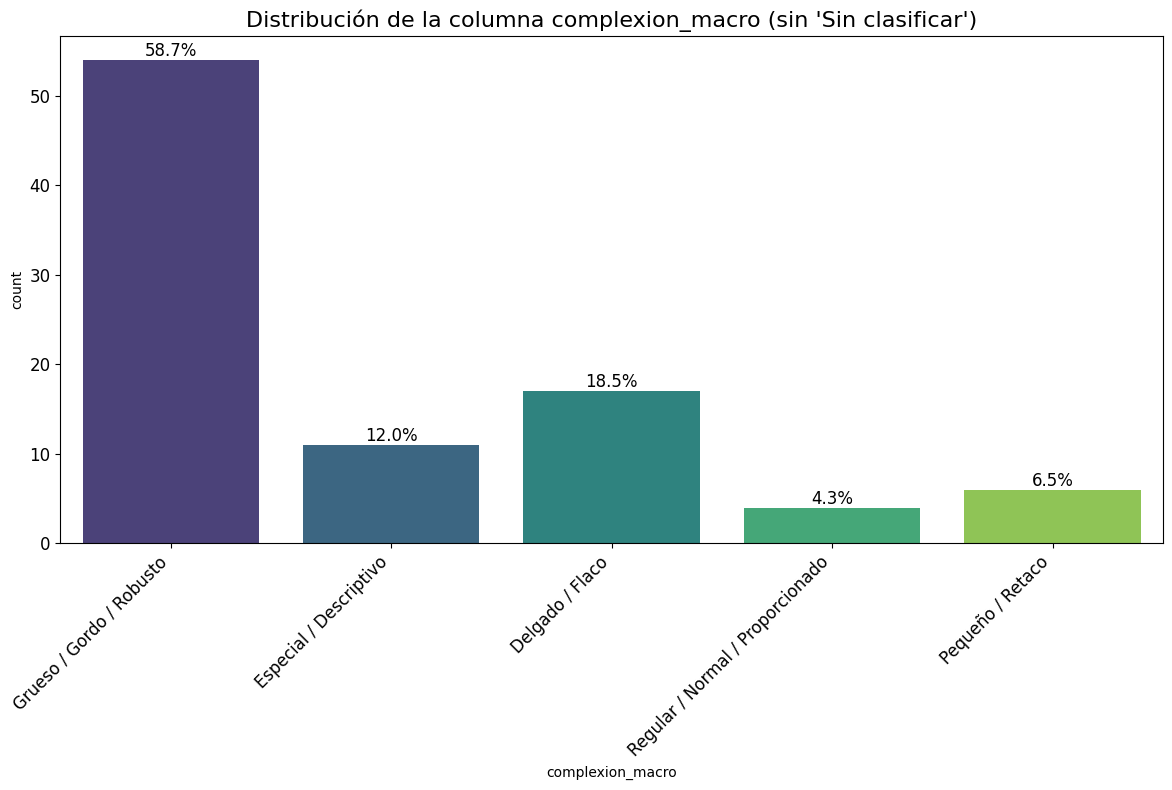

Distribución de la columna 'cara_macro' sin 'Sin clasificar':
cara_macro
Forma geométrica / estructura    79.850746
Tamaño / proporción               8.955224
Valoración estética               5.970149
Rasgos especiales                 2.238806
Edad / estado / apariencia        2.238806
Regular / neutral                 0.746269
Name: proportion, dtype: float64




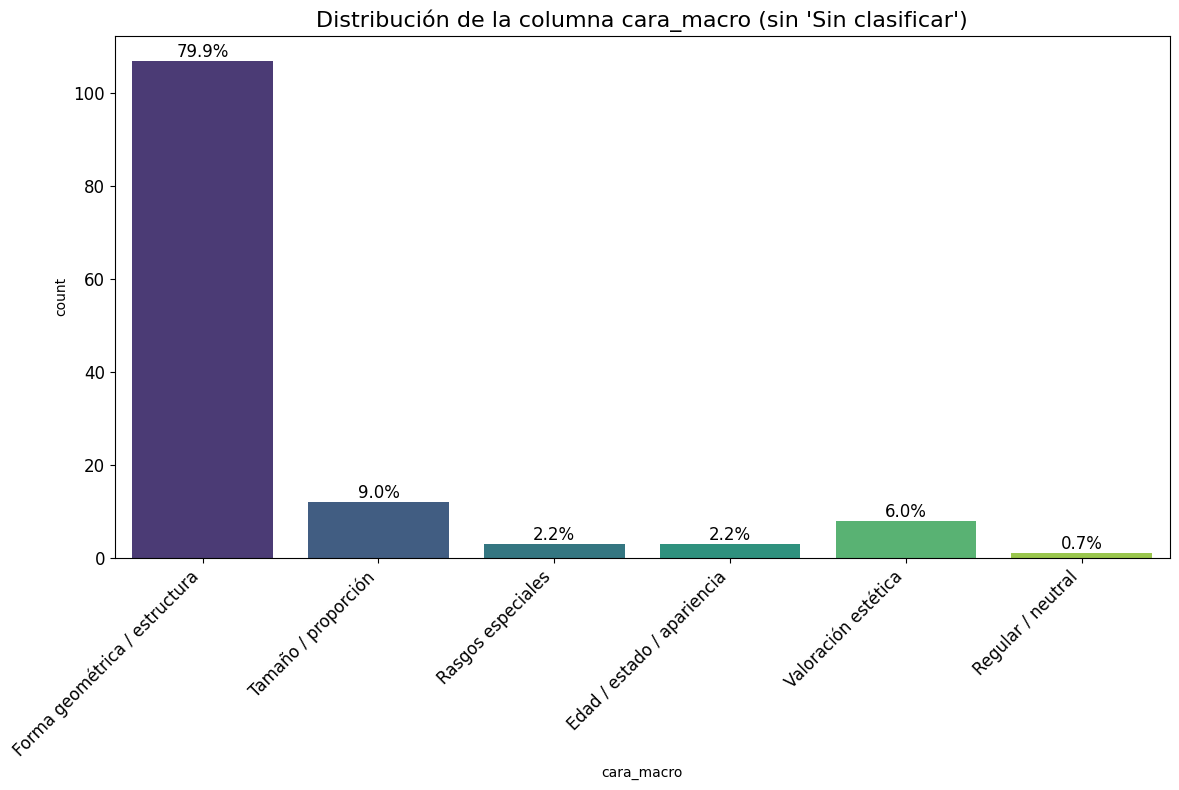

Distribución de la columna 'ojos_macro' sin 'Sin clasificar':
ojos_macro
pequeños                       24.210526
grandes                        23.157895
Mixta                          17.894737
defecto ocular                 10.526316
negros                          8.421053
expresivos / forma especial     7.368421
pardos                          4.210526
regulares                       3.157895
azules / claros                 1.052632
Name: proportion, dtype: float64




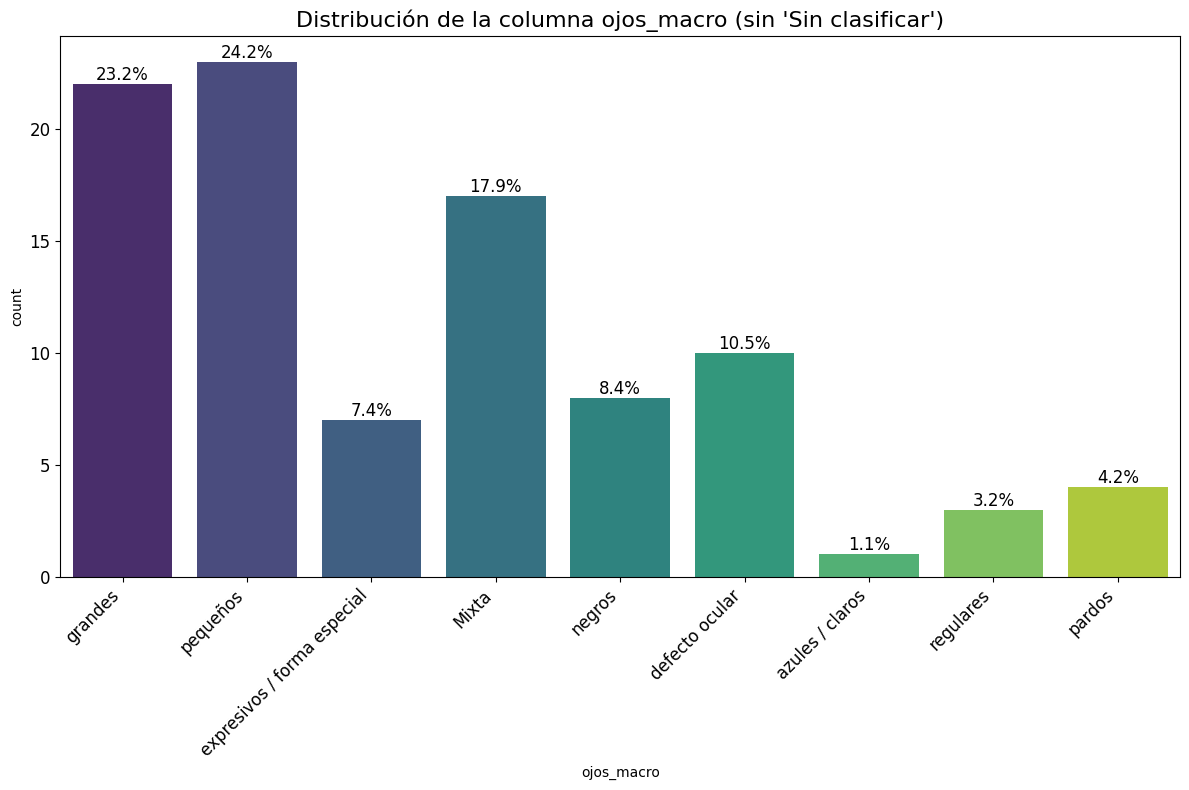

Distribución de la columna 'nariz_macro' sin 'Sin clasificar':
nariz_macro
Ñata                    44.680851
Afilada                 10.638298
Regular / Normal         8.510638
Grande / Narigona        8.510638
Aguileña                 7.446809
Chata                    6.382979
Roma                     4.255319
Mixta                    4.255319
Con señas o detalles     3.191489
Pequeña                  1.063830
Delgada                  1.063830
Name: proportion, dtype: float64




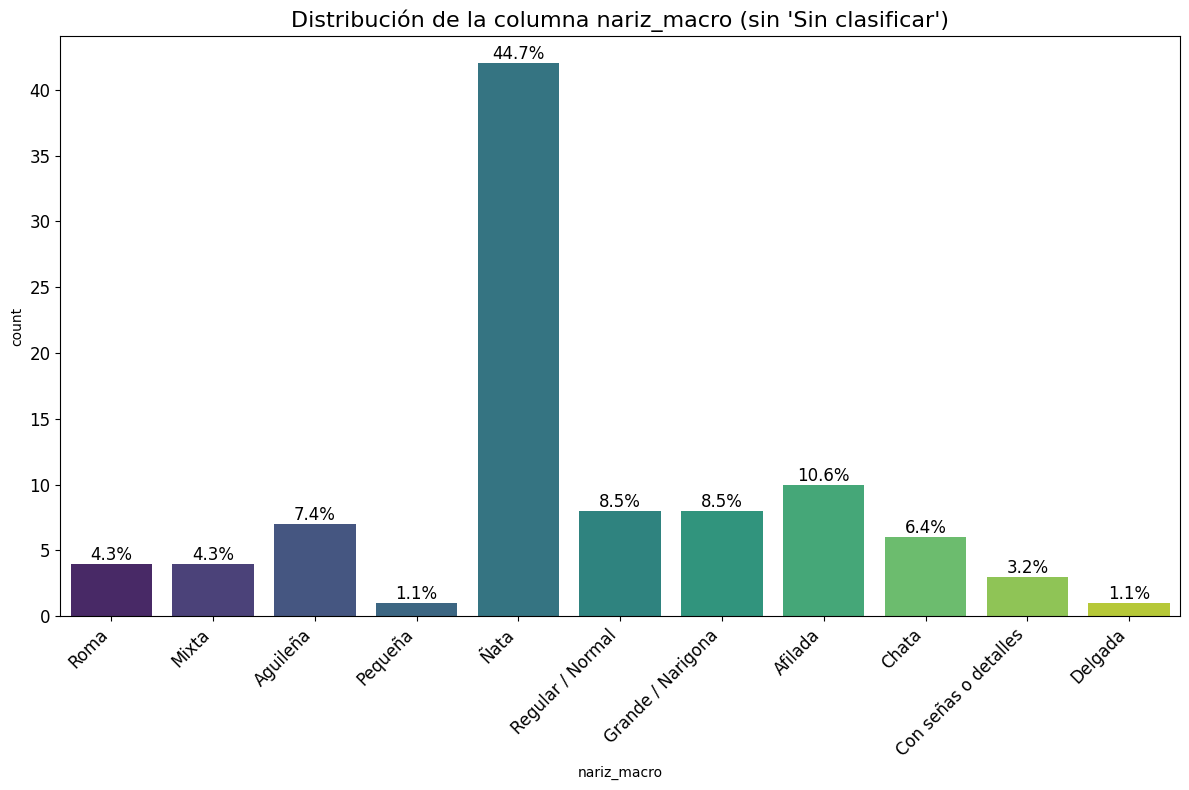

Distribución de la columna 'boca_macro' sin 'Sin clasificar':
boca_macro
Grande / Bocona / Jetona / Hocicona    56.818182
Pequeña / Chica                        22.727273
Regular / Normal                       20.454545
Name: proportion, dtype: float64




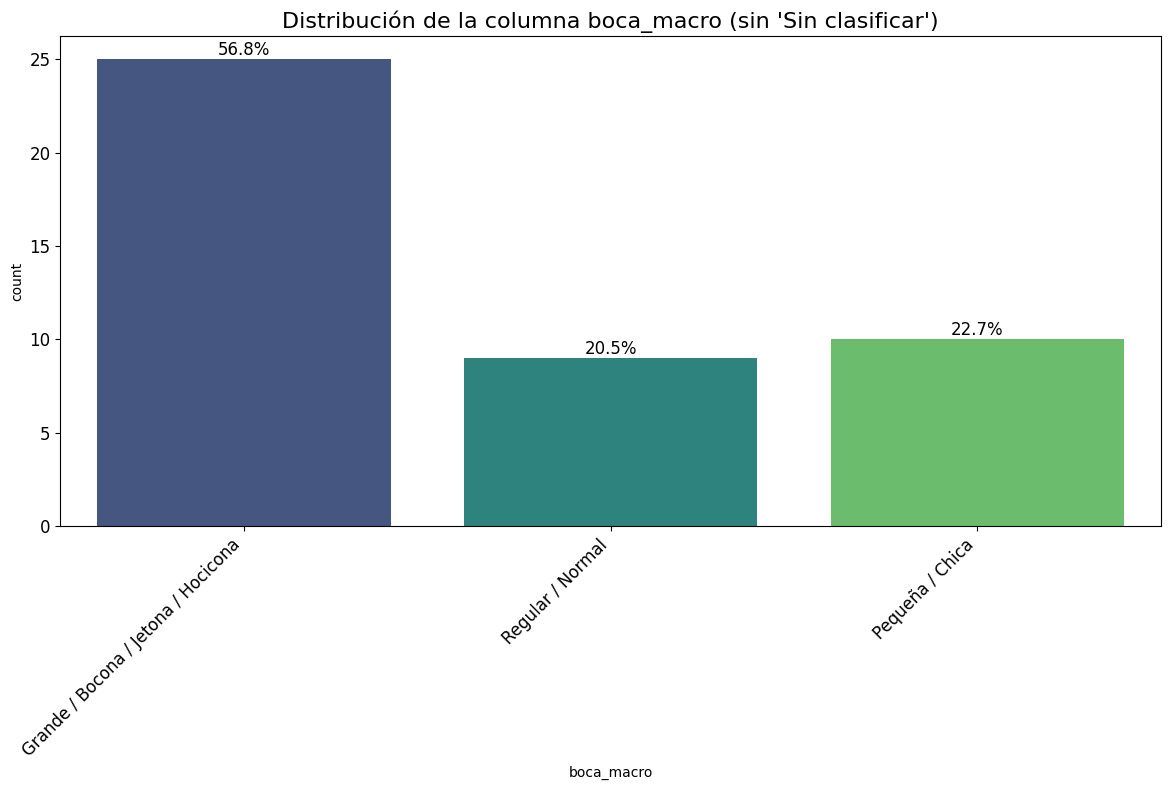

Distribución de la columna 'frente_macro' sin 'Sin clasificar':
frente_macro
Chica / Pequeña               57.142857
Estrecha / Hundida / Chata    21.428571
Calzada                       14.285714
Con señas o detalles           7.142857
Name: proportion, dtype: float64




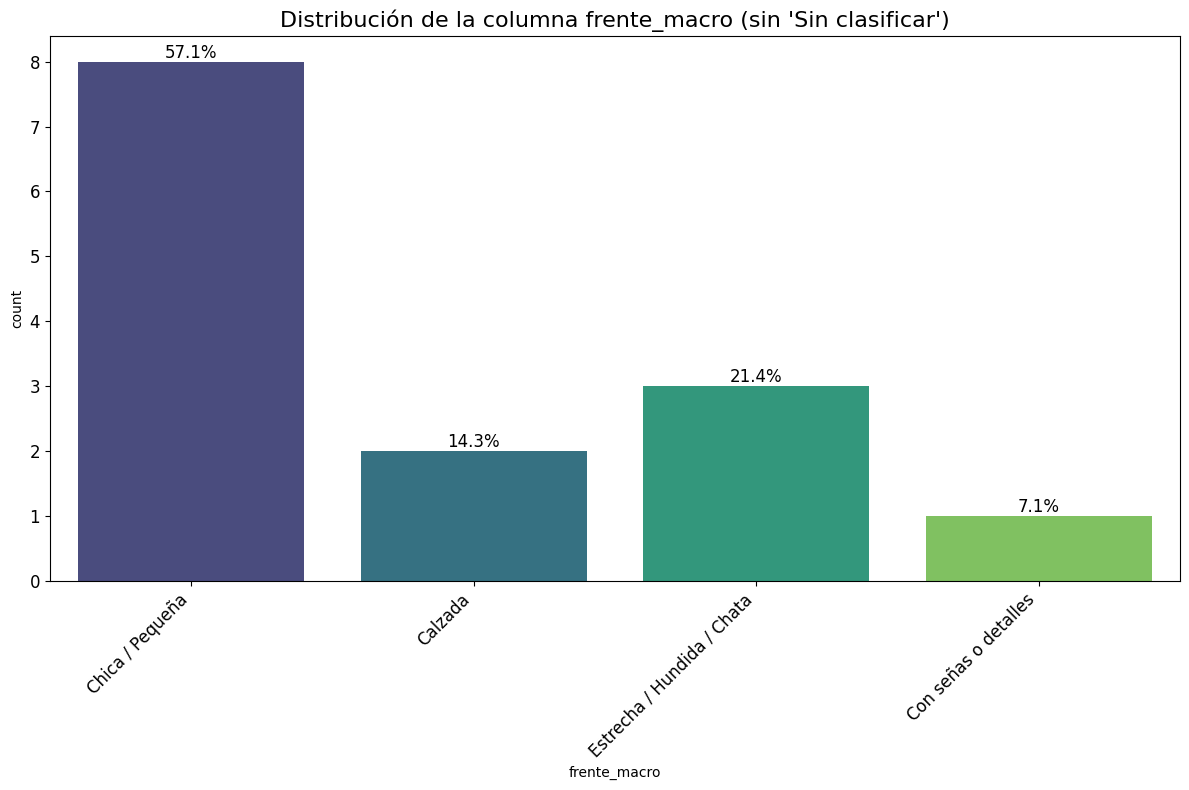

Distribución de la columna 'longitud_cabello_macro' sin 'Sin clasificar':
longitud_cabello_macro
Corto / Cortado / Recortado    52.542373
Pelona / Rapada / Sin pelo     28.813559
Largo / Trenzas largas         11.864407
Cantidad de pelo                5.084746
Con señas o detalles            1.694915
Name: proportion, dtype: float64




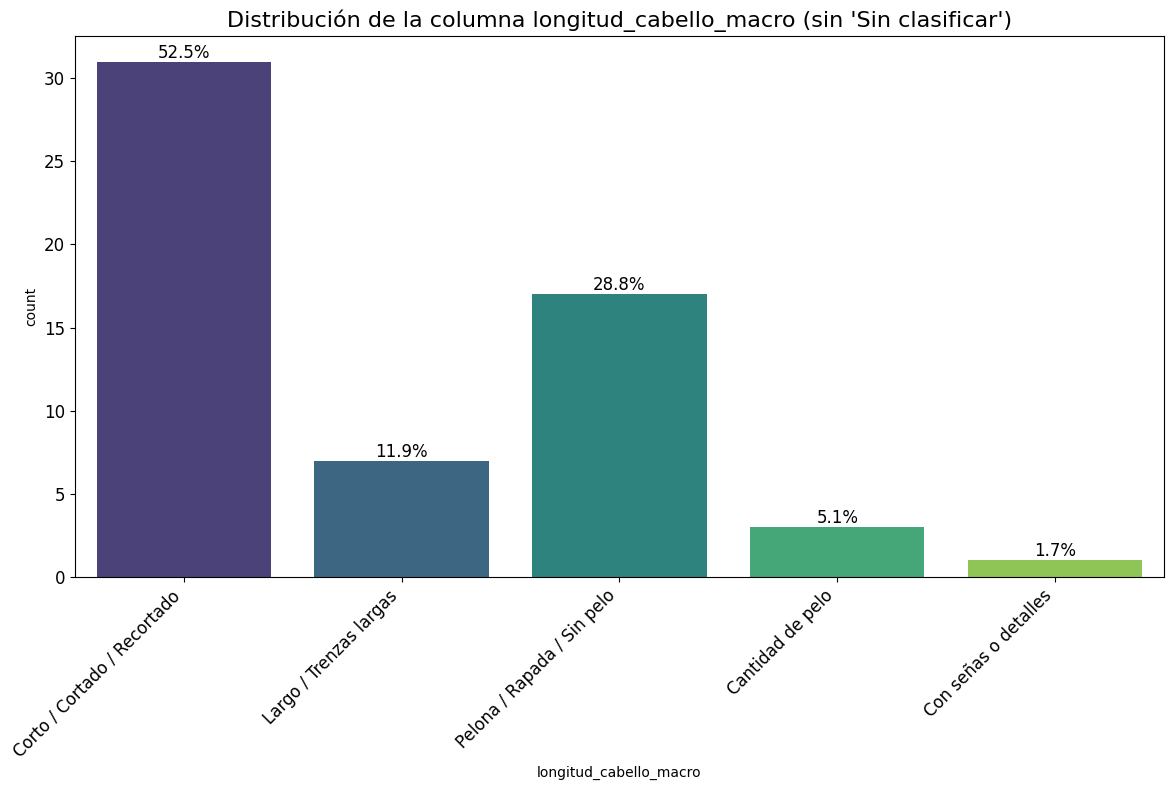

Distribución de la columna 'peinado_macro' sin 'Sin clasificar':
peinado_macro
Corto / Muy corto / Más corto que largo    32.142857
Pelona / Rapada / Pelado                   21.428571
Trenzas                                    14.285714
Lacio / Crespo                             14.285714
Otros / Con señas o detalles                7.142857
Largo / Suelto                              7.142857
Cantidad de pelo                            3.571429
Name: proportion, dtype: float64




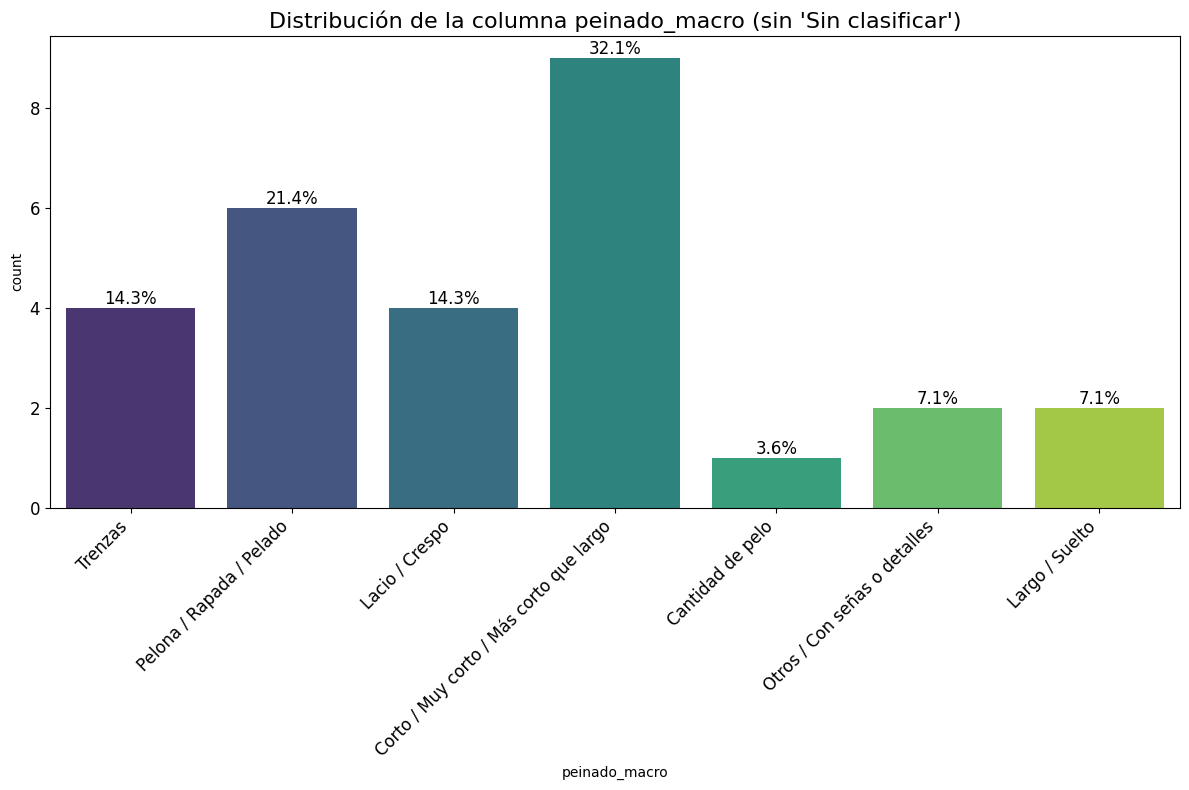

Distribución de la columna 'camisa_macro' sin 'Sin clasificar':
camisa_macro
Camisa              37.398374
Traje               30.081301
Vestido             11.382114
Chaqueta             9.756098
Mangas de camisa     5.691057
Levita               1.626016
Tuin                 1.626016
Camison              0.813008
Camisita             0.813008
Otros                0.813008
Name: proportion, dtype: float64




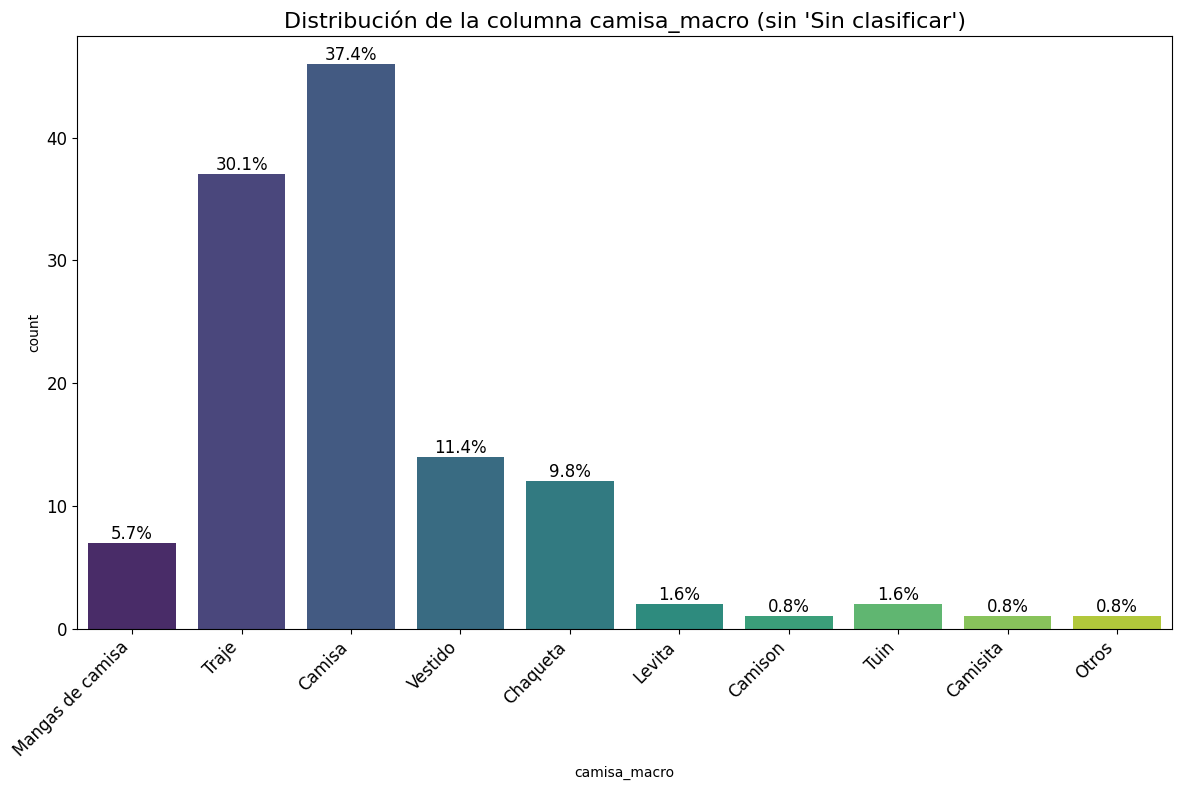

Distribución de la columna 'pantalon_macro' sin 'Sin clasificar':
pantalon_macro
Azul                                         38.356164
Rayado / Listado / Cuadros                   17.808219
Casimir / Paño / Lana / Seda / Cordellate    12.328767
Plomo / Gris                                  5.479452
Roto / Viejo / Usado                          5.479452
Blanco                                        4.109589
Negro                                         4.109589
Cabritilla                                    2.739726
Verde                                         2.739726
Oscuro (genérico)                             2.739726
Algodón / Brin / Dril / Mezclilla             1.369863
Amotape / Chohe / Choleta / Macedonia         1.369863
Sin pantalón                                  1.369863
Name: proportion, dtype: float64




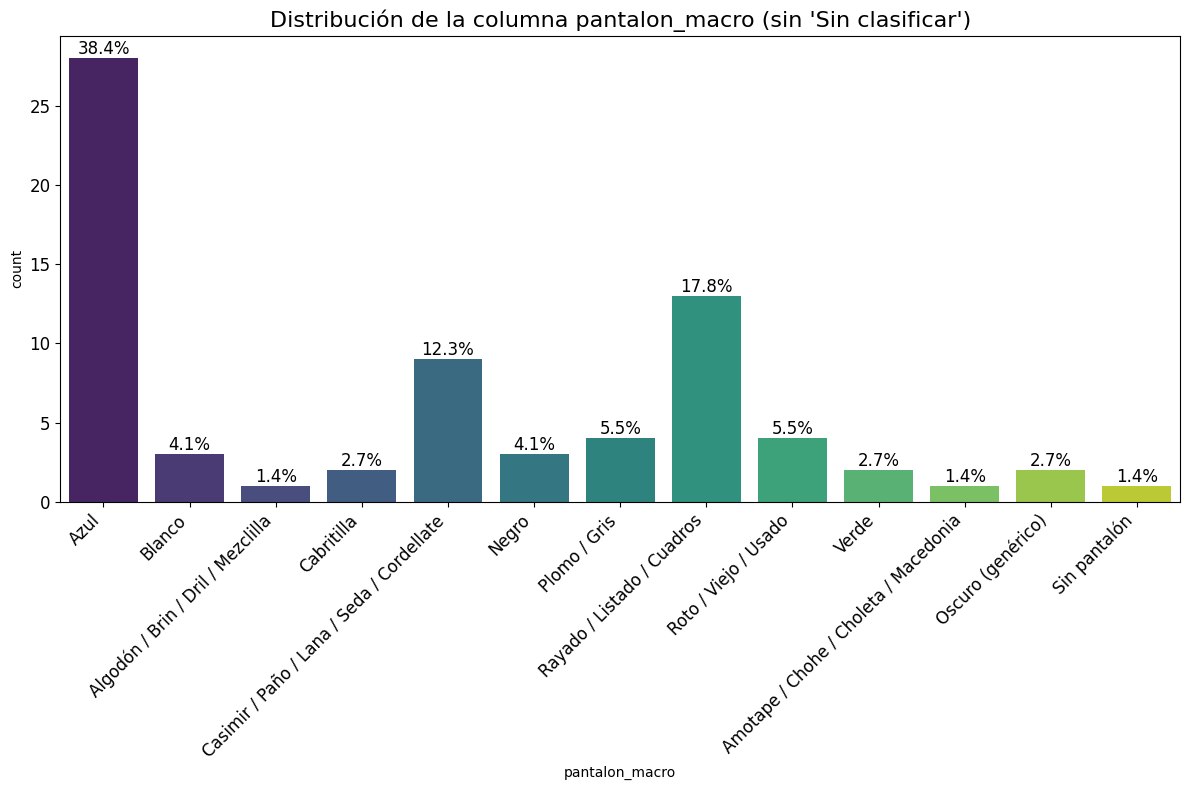

Distribución de la columna 'color_piel_macro' sin 'Sin clasificar':
color_piel_macro
Cholos/Chinas             67.867868
Mestizos                  11.111111
Trigueños/Tostados         6.606607
Indígena                   5.105105
Peruanos                   3.303303
Blancos/Claros             2.402402
Pardos/Prietos/Mulatos     2.402402
Amarillo/Amarillento       0.600601
Territorial                0.600601
Name: proportion, dtype: float64




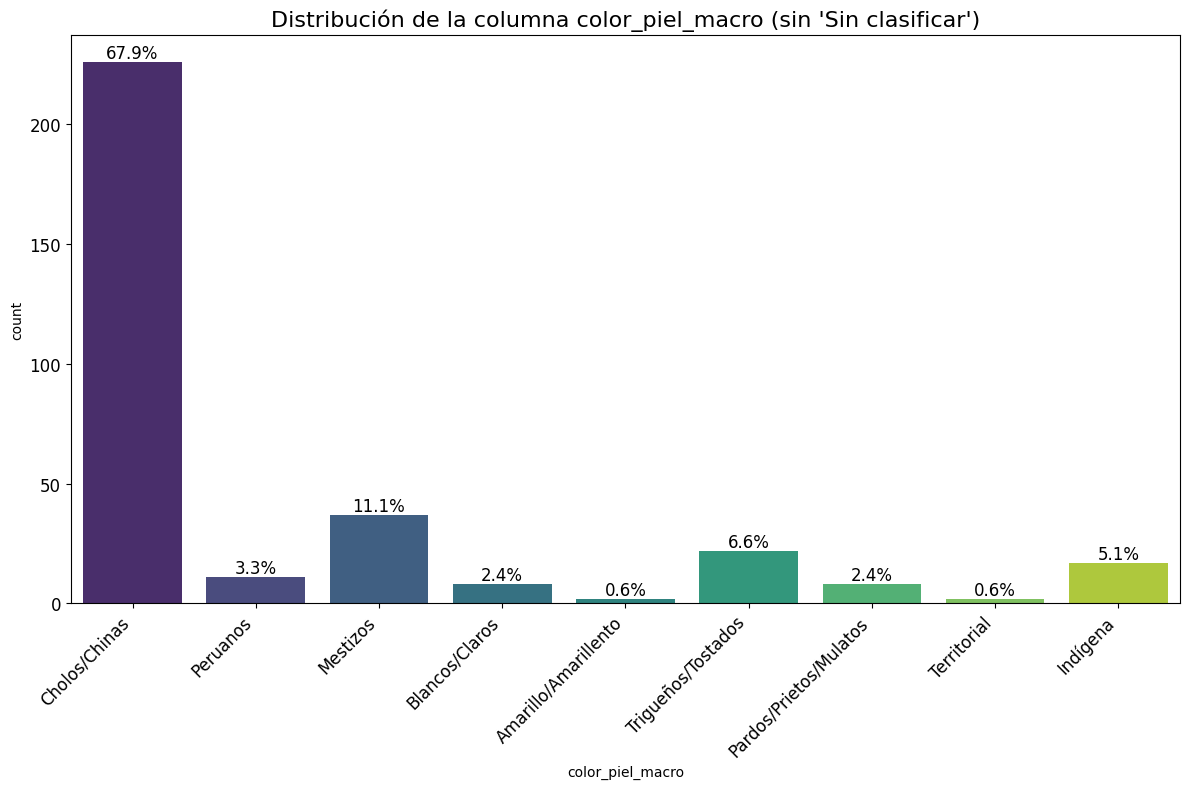

In [19]:
nuevas_columnas = [
    'edad_num', 'estatura_macro', 'complexion_macro', 'cara_macro',
    'ojos_macro', 'nariz_macro', 'boca_macro', 'frente_macro',
    'longitud_cabello_macro', 'peinado_macro', 'camisa_macro',
    'pantalon_macro', 'color_piel_macro'
]

for columna in nuevas_columnas:
    df_filtrado = df_avisos_cholitos[df_avisos_cholitos[columna] != "Sin clasificar"]
    
    valor_counts = df_filtrado[columna].value_counts(normalize=True) * 100
    
    print(f"Distribución de la columna '{columna}' sin 'Sin clasificar':")
    print(valor_counts)
    print("\n")
    
    plt.figure(figsize=(12, 8))
    sns.countplot(data=df_filtrado, x=columna, palette='viridis', hue=columna, legend=False)
    
    total = len(df_filtrado)
    for p in plt.gca().patches:
        height = p.get_height()
        width = p.get_width()
        x = p.get_x() + width / 2
        y = p.get_y() + height
        percentage = (height / total) * 100
        plt.text(x, y, f'{percentage:.1f}%', ha='center', fontsize=12, va='bottom', color='black')
    
    plt.title(f"Distribution of Column '{columna}' (Excluding 'Sin clasificar')", fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

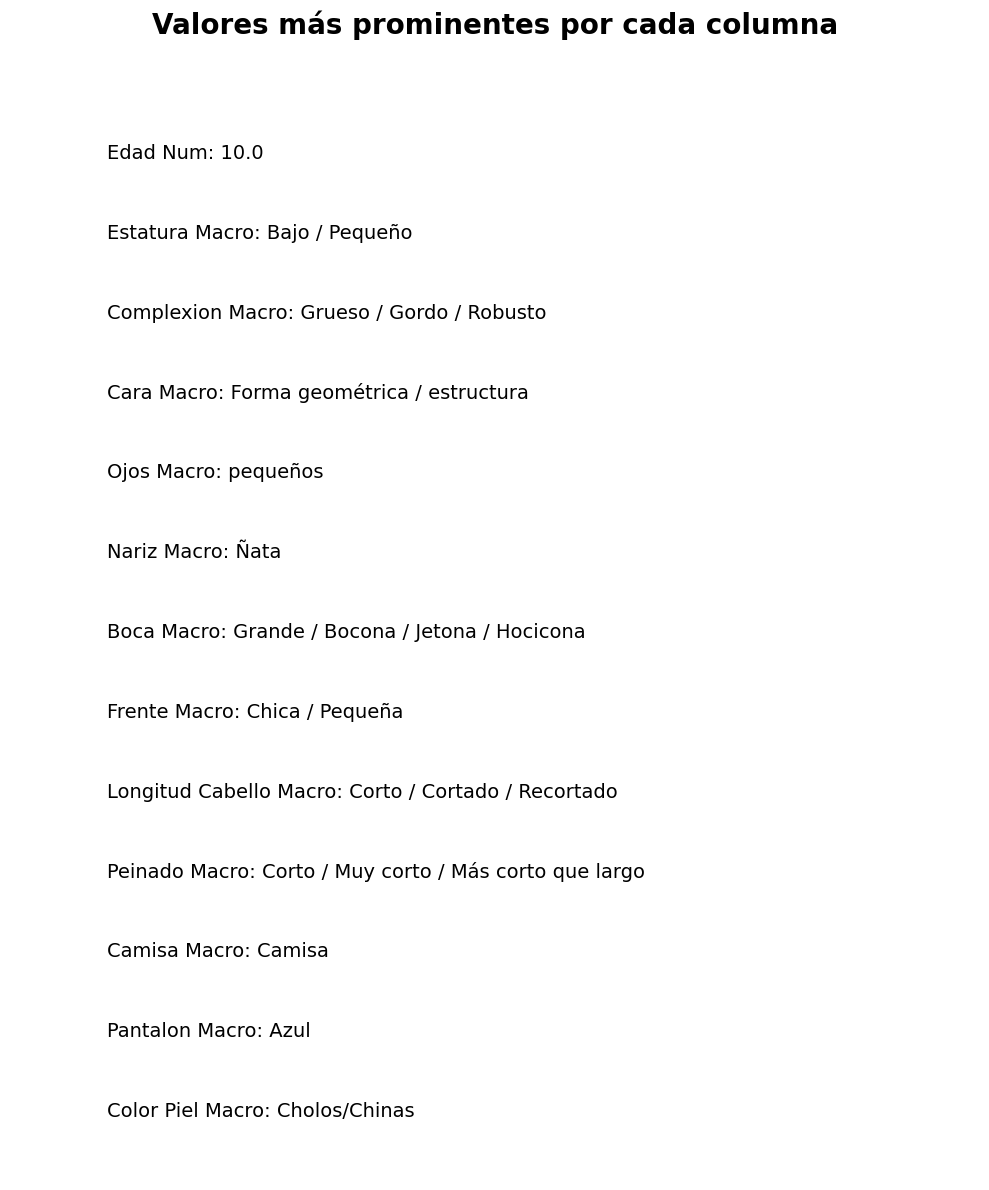

In [20]:
fig, ax = plt.subplots(figsize=(10, 12))

ax.axis('off')

ax.text(0.5, 1, 'Most Prominent Values by Column', ha='center', va='bottom', fontsize=20, fontweight='bold')

y_pos = 0.9

for columna in nuevas_columnas:
    moda = df_avisos_cholitos[df_avisos_cholitos[columna] != 'Sin clasificar'][columna].mode()[0]
    
    ax.text(0.1, y_pos, f"{columna.replace('_', ' ').title()}: {moda}", ha='left', va='center', fontsize=14)
    
    y_pos -= 0.07

plt.tight_layout()
plt.savefig('../data/valores_prominentes.png')
plt.show()

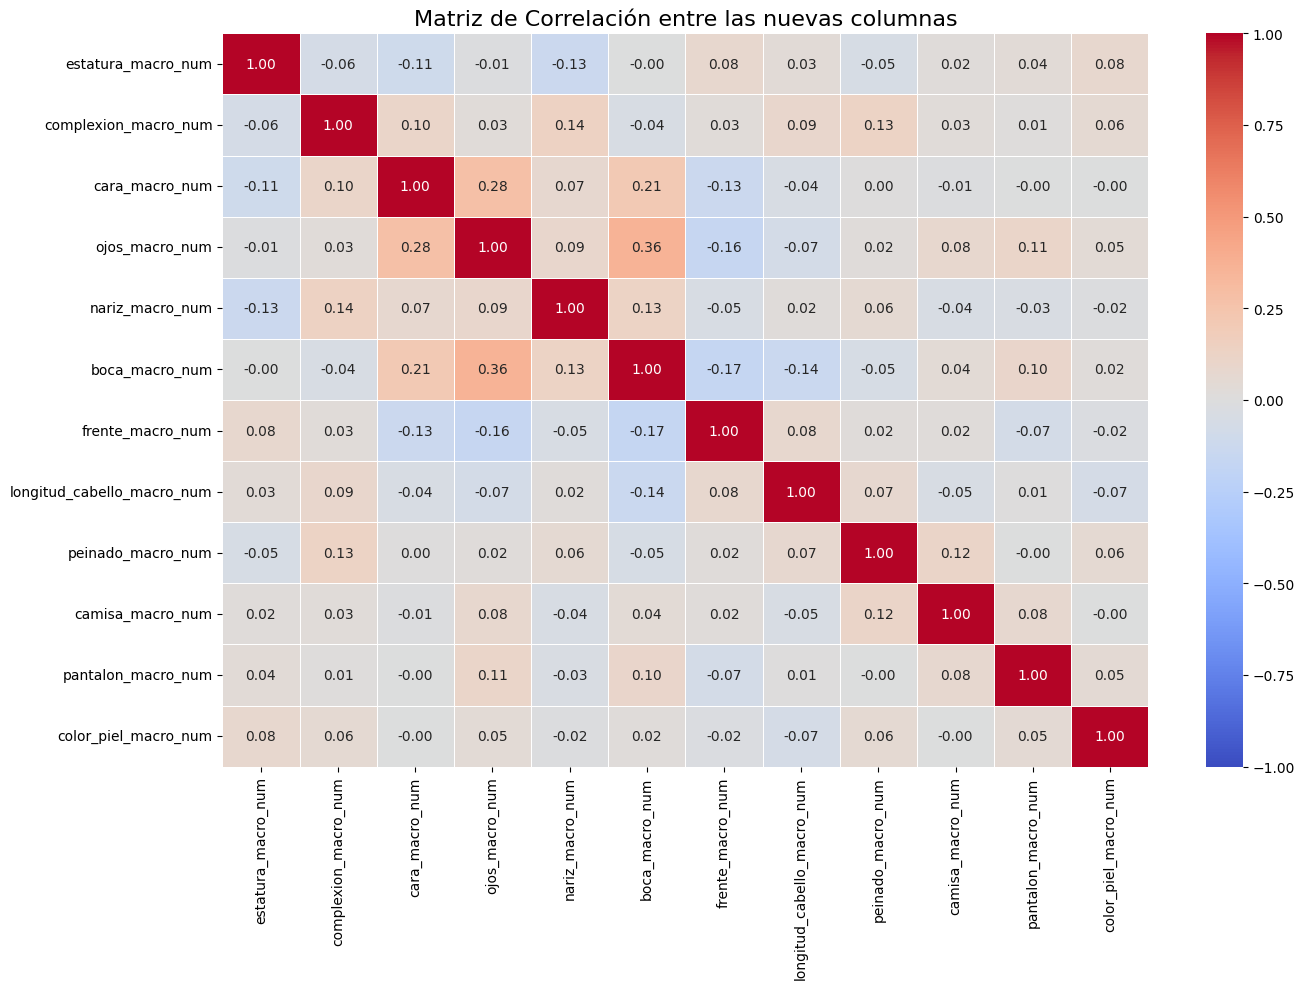

In [94]:
label_encoder = LabelEncoder()

for columna in nuevas_columnas:
    df_avisos_cholitos[columna] = df_avisos_cholitos[columna].replace('Sin clasificar', 'Desconocido')
    if df_avisos_cholitos[columna].dtype == 'str':
        df_avisos_cholitos[columna + '_num'] = label_encoder.fit_transform(df_avisos_cholitos[columna])

correlation_matrix = df_avisos_cholitos[[columna + '_num' for columna in nuevas_columnas if df_avisos_cholitos[columna].dtype == 'str']].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix Among the New Columns", fontsize=16)
plt.tight_layout()
plt.show()

In [95]:
from scipy.stats import chi2_contingency

for i, columna1 in enumerate(nuevas_columnas):
    for columna2 in nuevas_columnas[i+1:]:
        contingency_table = pd.crosstab(df_avisos_cholitos[columna1], df_avisos_cholitos[columna2])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"Prueba de Chi-cuadrado entre '{columna1}' y '{columna2}':")
        print(f"Valor p: {p}")
        print(f"Rechazamos la hipótesis nula si p < 0.05")
        print("\n")


Prueba de Chi-cuadrado entre 'edad_num' y 'estatura_macro':
Valor p: 1.314818368724208e-07
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'complexion_macro':
Valor p: 1.144195026683862e-05
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'cara_macro':
Valor p: 0.9999999999911151
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'ojos_macro':
Valor p: 2.1469983978396578e-06
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'nariz_macro':
Valor p: 0.3647283362151444
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'boca_macro':
Valor p: 0.9776650735464463
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'frente_macro':
Valor p: 0.9999999958007406
Rechazamos la hipótesis nula si p < 0.05


Prueba de Chi-cuadrado entre 'edad_num' y 'longitud_cabello_macro':
Valor p: 0.999999998

## Conversion of DataFrames to `.csv`

In [96]:
df_avisos_cholitos.to_csv(
    "../data/df_avisos_cholitos.csv", index=False, encoding="utf-8"
)
df_fuentes.to_csv("../data/df_fuentes.csv", index=False, encoding="utf-8")
df_fuentes_por_aviso.to_csv("../data/df_fuentes_por_aviso.csv", index=False, encoding="utf-8")

## Conversion of `procesamiento_inicial.ipynb` to `.procesamiento_inicial.pdf`

In [97]:
# export_notebook_to_pdf("procesamiento_inicial.ipynb")